## Setup and verified binary labels

Malignant: BCC/MEL/SCC = indices 1/4/6. AK is grouped as non-malignant for this task, not as healthy skin. Re-running setup creates a new run folder.


In [9]:
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import sys
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from scipy.optimize import minimize_scalar
from scipy.special import expit, logsumexp, softmax
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

# CHANGE ONLY THIS PATH if the project is in a different folder.
PROJECT_PATH = Path(r"C:\SRS(ISIC_2019)")
DATASET_PATH = PROJECT_PATH / "Dataset"
# Optional ISIC metadata CSV with columns image and lesion_id (or patient_id).
METADATA_CSV = DATASET_PATH / "ISIC_2019_Training_Metadata.csv"

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4
MAX_EPOCHS = 20
WARMUP_EPOCHS = 3
PATIENCE = 4
MIN_DELTA = 1e-4
CHECK_EXACT_DUPLICATES = True
NUM_WORKERS = 0  # Safe for Windows notebooks.
RUN_FL = False  # The old FL section is an inactive reference only.

LABEL_NAMES = ("AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC")
classes = list(LABEL_NAMES)
MALIGNANT_INDICES = (1, 4, 6)
malignant_classes = list(MALIGNANT_INDICES)


def get_binary_label(label):
    label = int(label)
    if not 0 <= label < 8:
        raise ValueError(f"Invalid class label: {label}")
    return int(label in MALIGNANT_INDICES)


assert [get_binary_label(i) for i in range(8)] == [0, 1, 0, 0, 1, 0, 1, 0]


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"

if not DATASET_PATH.is_dir():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATASET_PATH}. Fix PROJECT_PATH first."
    )

RUN_DIR = (
    PROJECT_PATH
    / "centralized_runs"
    / (datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_" + uuid4().hex[:8])
)
RUN_DIR.mkdir(parents=True, exist_ok=False)

config = {
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "accumulation_steps": ACCUMULATION_STEPS,
    "max_epochs": MAX_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "patience": PATIENCE,
    "min_delta": MIN_DELTA,
    "classes": list(LABEL_NAMES),
    "malignant_indices": list(MALIGNANT_INDICES),
    "initialization": "Fresh ImageNet backbones; fresh task heads; no old ISIC checkpoint",
    "binary_loss_weight": 0.5,
    "training_class_weights": "normalized inverse square root counts",
    "protocol": "centralized only; train/validation/calibration/test separated",
    "python": platform.python_version(),
    "device": str(device),
}
(RUN_DIR / "config.json").write_text(
    json.dumps(config, indent=2), encoding="utf-8"
)

packages = [
    "torch",
    "torchvision",
    "timm",
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "pillow",
    "matplotlib",
    "tqdm",
]
(RUN_DIR / "environment.txt").write_text(
    "\n".join(
        f"{name}=={importlib.metadata.version(name)}" for name in packages
    ),
    encoding="utf-8",
)

print("Binary label mapping verified:", malignant_classes)
print("Device:", device, "| Run:", RUN_DIR)
if device.type == "cpu":
    print(
        "CPU selected: four-backbone training will be slow. Check the notebook GPU environment."
    )


Binary label mapping verified: [1, 4, 6]
Device: cuda | Run: C:\SRS(ISIC_2019)\centralized_runs\20260922_113709_95c8f881


### Step 1 — Backup baseline and prepare fine-tuning folder(2nd tuning)

In [22]:
from pathlib import Path
from datetime import datetime
from uuid import uuid4
import hashlib
import json
import shutil
import os


PROJECT_PATH = Path(r"C:\SRS(ISIC_2019)")

# আগের সম্পূর্ণ training run।
BASELINE_RUN = (
    PROJECT_PATH
    / "centralized_runs"
    / "20260922_025359_c4131415"
)

BASELINE_MODEL_PATH = BASELINE_RUN / "best_centralized_model.pth"

# একই baseline-এর backup বারবার তৈরি হবে না।
BACKUP_DIR = PROJECT_PATH / "baseline_backups" / BASELINE_RUN.name


def sha256_file(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()


# 1. প্রয়োজনীয় source files আছে কি না দেখো।
required_files = [
    "best_centralized_model.pth",
    "calibration.json",
    "config.json",
    "split_train.csv",
    "split_validation.csv",
    "split_calibration.csv",
    "split_test.csv",
    "training_history.csv",
]

missing = [
    name for name in required_files
    if not (BASELINE_RUN / name).is_file()
]

if missing:
    raise FileNotFoundError(
        f"Missing files in {BASELINE_RUN}:\n"
        + "\n".join(missing)
    )

source_files = sorted(
    path for path in BASELINE_RUN.rglob("*")
    if path.is_file()
)

if not source_files:
    raise RuntimeError("Baseline folder is empty.")


# 2. পুরো baseline folder backup করো।
# অসম্পূর্ণ copy-কে final backup হিসেবে ব্যবহার করা হবে না।
if not BACKUP_DIR.exists():
    BACKUP_DIR.parent.mkdir(parents=True, exist_ok=True)

    temporary_backup = BACKUP_DIR.with_name(
        BACKUP_DIR.name + "_copying_" + uuid4().hex[:8]
    )

    print("Copying baseline model and results...")

    shutil.copytree(BASELINE_RUN, temporary_backup)

    for source in source_files:
        relative = source.relative_to(BASELINE_RUN)
        copied = temporary_backup / relative

        if sha256_file(source) != sha256_file(copied):
            raise RuntimeError(
                f"Backup verification failed: {relative}\n"
                f"Incomplete copy retained at: {temporary_backup}"
            )

    os.replace(temporary_backup, BACKUP_DIR)
    print("Baseline backup created and verified.")

else:
    # পুরোনো backup overwrite না করে যাচাই করো।
    print("Existing backup found. Verifying...")

    for source in source_files:
        relative = source.relative_to(BASELINE_RUN)
        copied = BACKUP_DIR / relative

        if not copied.is_file():
            raise RuntimeError(
                f"Existing backup is missing: {relative}"
            )

        if sha256_file(source) != sha256_file(copied):
            raise RuntimeError(
                f"Source and backup differ: {relative}. "
                "Neither file was overwritten."
            )

    print("Existing baseline backup verified.")


# 3. এই kernel session-এ cell আবার চালালে একই folder রাখবে।
if "FT_RUN_DIR" not in globals():
    run_name = (
        "cb_finetune_"
        + datetime.now().strftime("%Y%m%d_%H%M%S")
        + "_"
        + uuid4().hex[:8]
    )

    FT_RUN_DIR = PROJECT_PATH / "centralized_finetuning_runs" / run_name
    FT_RUN_DIR.mkdir(parents=True, exist_ok=False)

    experiment_info = {
        "baseline_run": str(BASELINE_RUN),
        "baseline_backup": str(BACKUP_DIR),
        "baseline_model_sha256": sha256_file(BASELINE_MODEL_PATH),
        "planned_multiclass_loss": "Effective-number Class-Balanced CE",
        "split_policy": "Reuse saved baseline splits",
        "status": "Prepared; training has not started",
    }

    (FT_RUN_DIR / "experiment_info.json").write_text(
        json.dumps(experiment_info, indent=2),
        encoding="utf-8",
    )

else:
    FT_RUN_DIR = Path(FT_RUN_DIR)
    info_path = FT_RUN_DIR / "experiment_info.json"

    if not info_path.is_file():
        raise RuntimeError(
            "FT_RUN_DIR exists in memory but its experiment file is missing."
        )

    experiment_info = json.loads(info_path.read_text(encoding="utf-8"))

    if (
        experiment_info["baseline_model_sha256"]
        != sha256_file(BASELINE_MODEL_PATH)
    ):
        raise RuntimeError("Fine-tuning folder refers to another baseline.")

    print("Reusing this session's fine-tuning folder.")


print("\nSTEP 1 COMPLETED")
print("Baseline model:", BASELINE_MODEL_PATH)
print("Verified backup:", BACKUP_DIR)
print("Fine-tuning output:", FT_RUN_DIR)
print("Training started: NO")
print("Original model and results: unchanged")

Copying baseline model and results...
Baseline backup created and verified.

STEP 1 COMPLETED
Baseline model: C:\SRS(ISIC_2019)\centralized_runs\20260922_025359_c4131415\best_centralized_model.pth
Verified backup: C:\SRS(ISIC_2019)\baseline_backups\20260922_025359_c4131415
Fine-tuning output: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260922_183948_69fb119f
Training started: NO
Original model and results: unchanged


## Original data and disjoint splits(2nd tuning)


In [23]:
from pathlib import Path
from itertools import combinations
import hashlib
import shutil

import numpy as np
import pandas as pd
from IPython.display import display


# Step 1 চালানো হয়েছে কি না পরীক্ষা।
if not all(
    name in globals()
    for name in ("BASELINE_RUN", "BACKUP_DIR", "FT_RUN_DIR")
):
    raise RuntimeError("আগে Step 1 backup cell চালাও।")

LABEL_NAMES = (
    "AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"
)
MALIGNANT_INDICES = (1, 4, 6)

split_names = ("train", "validation", "calibration", "test")
required_columns = (
    "image_path", "image_id", "label", "group_id", "sha256"
)


def split_file_hash(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()


# 1. Baseline-এর manifest backup-এর সঙ্গে মিলিয়ে load।
restored_splits = {}

for name in split_names:
    source = BASELINE_RUN / f"split_{name}.csv"
    backup = BACKUP_DIR / source.name

    if not source.is_file() or not backup.is_file():
        raise FileNotFoundError(
            f"Source or backup manifest missing: {source.name}"
        )

    if split_file_hash(source) != split_file_hash(backup):
        raise ValueError(
            f"Baseline manifest changed after backup: {source.name}"
        )

    frame = pd.read_csv(
        source,
        dtype={
            "image_path": str,
            "image_id": str,
            "group_id": str,
            "sha256": str,
        },
    )

    if not set(required_columns).issubset(frame.columns):
        raise ValueError(f"Missing manifest columns: {name}")

    if frame.empty or frame[list(required_columns)].isna().any().any():
        raise ValueError(f"Empty or incomplete manifest: {name}")

    for column in ("image_path", "image_id", "group_id", "sha256"):
        if frame[column].str.strip().eq("").any():
            raise ValueError(f"Blank {column} in {name}")

    labels = pd.to_numeric(frame["label"], errors="raise")

    if not labels.isin(range(len(LABEL_NAMES))).all():
        raise ValueError(f"Invalid class labels: {name}")

    frame["label"] = labels.astype(int)

    if set(frame["label"]) != set(range(len(LABEL_NAMES))):
        raise ValueError(f"A class is missing from {name}")

    if frame["image_id"].str.casefold().duplicated().any():
        raise ValueError(f"Repeated image IDs in {name}")

    if not frame["sha256"].str.fullmatch(r"[0-9a-fA-F]{64}").all():
        raise ValueError(f"Invalid image hashes in {name}")

    restored_splits[name] = frame.reset_index(drop=True)


# 2. Split-গুলোর মধ্যে image, group ও recorded hash overlap পরীক্ষা।
for (name_a, a), (name_b, b) in combinations(
    restored_splits.items(), 2
):
    for column in ("image_id", "group_id", "sha256"):
        values_a = a[column]
        values_b = b[column]

        if column in ("image_id", "sha256"):
            values_a = values_a.str.casefold()
            values_b = values_b.str.casefold()

        if not set(values_a).isdisjoint(set(values_b)):
            raise ValueError(
                f"{column} overlap: {name_a} / {name_b}"
            )


# 3. Recorded image hashes-এর label conflict পরীক্ষা।
combined = pd.concat(restored_splits.values(), ignore_index=True)
combined["_hash"] = combined["sha256"].str.lower()

if combined.groupby("_hash")["label"].nunique().gt(1).any():
    raise ValueError("Conflicting labels remain in the saved manifests.")


# 4. সব image path এখনো পাওয়া যাচ্ছে কি না দেখো।
missing_images = [
    path for path in combined["image_path"]
    if not Path(path).is_file()
]

if missing_images:
    raise FileNotFoundError(
        f"{len(missing_images)} images were not found. Examples:\n"
        + "\n".join(missing_images[:5])
    )


# 5. নতুন experiment folder-এ exact manifest copies রাখো।
FT_RUN_DIR = Path(FT_RUN_DIR)

for name in split_names:
    source = BASELINE_RUN / f"split_{name}.csv"
    destination = FT_RUN_DIR / source.name

    if destination.exists():
        if split_file_hash(source) != split_file_hash(destination):
            raise ValueError(
                f"Fine-tuning manifest differs: {destination.name}"
            )
    else:
        shutil.copy2(source, destination)

    if split_file_hash(source) != split_file_hash(destination):
        raise RuntimeError(f"Copy verification failed: {source.name}")


# 6. পরের loader cell-এর জন্য variables।
train_df = restored_splits["train"]
val_df = restored_splits["validation"]
calibration_df = restored_splits["calibration"]
test_df = restored_splits["test"]

splits = restored_splits

# পরবর্তী output নতুন fine-tuning folder-এ যাবে।
RUN_DIR = FT_RUN_DIR


# 7. Class counts দেখাও।
summary = pd.DataFrame({
    name: frame["label"].value_counts()
    for name, frame in restored_splits.items()
}).reindex(range(len(LABEL_NAMES))).fillna(0).astype(int)

summary.index = LABEL_NAMES
summary.index.name = "class"

summary.to_csv(FT_RUN_DIR / "split_counts.csv")

print("STEP 2 COMPLETED")
print("Saved baseline splits restored.")
print("Manifest image/group/hash overlap checks: PASSED")
print("Image paths available:", len(combined))
print("New splitting or oversampling: NO")
print("Training started: NO")
print("\nClass distribution:")
display(summary)

print("\nTotals:", {
    name: len(frame)
    for name, frame in restored_splits.items()
})
print("\nFine-tuning output folder:", FT_RUN_DIR)

STEP 2 COMPLETED
Saved baseline splits restored.
Manifest image/group/hash overlap checks: PASSED
Image paths available: 25327
New splitting or oversampling: NO
Training started: NO

Class distribution:


,train,validation,calibration,test
class,,,,
AK,609,86,43,129
BCC,2327,332,166,498
BKL,1835,262,132,395
DF,168,24,12,35
MEL,3164,452,226,678
NV,9012,1287,643,1931
SCC,438,63,32,95
VASC,178,26,12,37



Totals: {'train': 17731, 'validation': 2532, 'calibration': 1266, 'test': 3798}

Fine-tuning output folder: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260922_183948_69fb119f


## Transforms and loaders(2nd Tuning)

No oversampling. Augmentation applies to training only. Batch size 4 with four gradient accumulation steps gives a nominal effective batch size 16; BatchNorm still sees physical batches of 4.


In [24]:
import random

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# Step 2-এর restored dataframes প্রয়োজন।
required_variables = (
    "train_df", "val_df", "calibration_df", "test_df"
)

if not all(name in globals() for name in required_variables):
    raise RuntimeError("আগে Step 2 saved split restore cell চালাও।")


SEED = 42
IMG_SIZE = 224

# আগের baseline-এর batch settings।
BATCH_SIZE = 4
ACCUMULATION_STEPS = 4

# Windows notebook-এর জন্য আগের setting রাখছি।
NUM_WORKERS = 0

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
USE_AMP = device.type == "cuda"


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(SEED)


# 1. Augmentation শুধু training images-এর জন্য।
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


# 2. Validation/calibration/test-এর জন্য deterministic transform।
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class ISICDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row["image_path"]) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long,
        )

        return image, label


def make_loader(frame, training=False):
    return DataLoader(
        dataset=ISICDataset(
            frame,
            train_transform if training else val_transform,
        ),
        batch_size=BATCH_SIZE,
        shuffle=training,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
        generator=torch.Generator().manual_seed(SEED),
    )


# 3. Restored splits থেকে loaders।
train_loader = make_loader(train_df, training=True)
val_loader = make_loader(val_df)
calibration_loader = make_loader(calibration_df)
test_loader = make_loader(test_df)


# 4. Validation batch দিয়ে shape এবং values পরীক্ষা।
# Training loader-এর shuffle/augmentation state বদলাবে না।
sample_images, sample_labels = next(iter(val_loader))

if tuple(sample_images.shape[1:]) != (3, IMG_SIZE, IMG_SIZE):
    raise ValueError("Unexpected image tensor shape.")

if not torch.isfinite(sample_images).all():
    raise ValueError("Non-finite values found in image tensors.")

if sample_labels.dtype != torch.long:
    raise ValueError("Class labels must have torch.long dtype.")

if not ((sample_labels >= 0) & (sample_labels < 8)).all():
    raise ValueError("Invalid class labels.")


print("STEP 3 COMPLETED")
print("Configured compute device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(device))

print("\nDataset sizes:")
print("Train:", len(train_loader.dataset))
print("Validation:", len(val_loader.dataset))
print("Calibration:", len(calibration_loader.dataset))
print("Test:", len(test_loader.dataset))

print("\nBatches per epoch:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Calibration:", len(calibration_loader))
print("Test:", len(test_loader))

print("\nValidation batch shape:", tuple(sample_images.shape))
print("Label batch shape:", tuple(sample_labels.shape))
print("Batch checks: PASSED")

print("\nPhysical batch size:", BATCH_SIZE)
print("Gradient accumulation steps:", ACCUMULATION_STEPS)
print(
    "Nominal effective training batch:",
    BATCH_SIZE * ACCUMULATION_STEPS,
)

print("Training sampler:", type(train_loader.sampler).__name__)
print("Oversampling: NO")
print("Training started: NO")

STEP 3 COMPLETED
Configured compute device: cuda
GPU: NVIDIA GeForce RTX 4090

Dataset sizes:
Train: 17731
Validation: 2532
Calibration: 1266
Test: 3798

Batches per epoch:
Train: 4433
Validation: 633
Calibration: 317
Test: 950

Validation batch shape: (4, 3, 224, 224)
Label batch shape: (4,)
Batch checks: PASSED

Physical batch size: 4
Gradient accumulation steps: 4
Nominal effective training batch: 16
Training sampler: RandomSampler
Oversampling: NO
Training started: NO


## Four-backbone fusion model

Preserves EfficientNet-B3, ResNet50, DenseNet121 and ViT-small. Fresh task heads are trained on corrected targets. Backbone ImageNet weights are used, not the old ISIC checkpoint.


In [25]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x)
        x = x * ca

        # Spatial attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        sa = self.spatial_attention(torch.cat([avg_out, max_out], dim=1))
        x = x * sa

        return x


class MultiSampleDropout(nn.Module):
    def __init__(self, dropout_num=4, dropout_rate=0.5):
        super().__init__()
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(dropout_num)])

    def forward(self, x):
        outputs = []
        for dropout in self.dropouts:
            outputs.append(dropout(x))
        return outputs


class FeatureExtractor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.efficientnet = timm.create_model("efficientnet_b3", pretrained=pretrained, features_only=True)
        self.resnet = timm.create_model("resnet50", pretrained=pretrained, features_only=True)
        self.densenet = timm.create_model("densenet121", pretrained=pretrained, features_only=True)
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=pretrained)

    def forward(self, x):
        eff = self.efficientnet(x)[-1]
        res = self.resnet(x)[-1]
        dense = self.densenet(x)[-1]
        vit = self.vit.forward_features(x)

        return eff, res, dense, vit


class ISIC_Fusion_Model(nn.Module):
    def __init__(self, num_classes=8, pretrained=True):
        super().__init__()
        self.features = FeatureExtractor(pretrained=pretrained)

        # Actual feature channels: EfficientNet=384, ResNet=2048, DenseNet=1024, ViT=384 (Total = 3840)
        self.fusion = nn.Sequential(
            nn.Conv2d(3840, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        self.cbam = CBAM(512)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = MultiSampleDropout(dropout_num=4, dropout_rate=0.5)
        self.binary_classifier = nn.Linear(512, 1)
        self.class_classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        eff, res, dense, vit = self.features(x)

        # -----------------------------
        # ViT Feature Handling
        # -----------------------------
        if len(vit.shape) == 3:
            B, N, C = vit.shape

            # Remove CLS token (ViT output = [B, 197, 384])
            if N == 197:
                vit = vit[:, 1:, :]
                N = vit.shape[1]

            size = int(N ** 0.5)
            if size * size != N:
                raise ValueError(f"Unexpected ViT token count: {N}")
            vit = vit.permute(0, 2, 1)
            vit = vit.reshape(B, C, size, size)

        # -----------------------------
        # Resize feature maps
        # -----------------------------
        target_size = eff.shape[-2:]
        res = F.interpolate(res, size=target_size, mode="bilinear", align_corners=False)
        dense = F.interpolate(dense, size=target_size, mode="bilinear", align_corners=False)
        vit = F.interpolate(vit, size=target_size, mode="bilinear", align_corners=False)

        # -----------------------------
        # Feature Fusion
        # -----------------------------
        combined = torch.cat([eff, res, dense, vit], dim=1)
        x = self.fusion(combined)

        # CBAM Attention & Global pooling
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)

        # -----------------------------
        # Multi Sample Dropout
        # -----------------------------
        outputs = []
        dropout_features = self.dropout(x)

        for feature in dropout_features:
            binary_out = self.binary_classifier(feature)
            class_out = self.class_classifier(feature)
            outputs.append((binary_out, class_out))

        return outputs


### Step 4 — Load baseline weights for fine-tuning(2nd tuning)

In [26]:
from pathlib import Path
import hashlib

import torch


# আগের steps-এর প্রয়োজনীয় variables।
required_variables = (
    "BASELINE_MODEL_PATH",
    "FT_RUN_DIR",
    "ISIC_Fusion_Model",
    "LABEL_NAMES",
    "MALIGNANT_INDICES",
    "device",
    "IMG_SIZE",
)

missing = [
    name for name in required_variables
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "আগের steps ও architecture cell চালাও। Missing: "
        + ", ".join(missing)
    )


def checkpoint_sha256(path):
    hasher = hashlib.sha256()

    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)

    return hasher.hexdigest()


# 1. Baseline checkpoint load।
BASELINE_MODEL_PATH = Path(BASELINE_MODEL_PATH)

if not BASELINE_MODEL_PATH.is_file():
    raise FileNotFoundError(BASELINE_MODEL_PATH)

baseline_checkpoint = torch.load(
    BASELINE_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

if tuple(baseline_checkpoint["classes"]) != tuple(LABEL_NAMES):
    raise ValueError("Checkpoint class order mismatch.")

if tuple(baseline_checkpoint["malignant_indices"]) != tuple(
    MALIGNANT_INDICES
):
    raise ValueError("Checkpoint binary label mapping mismatch.")

checkpoint_image_size = baseline_checkpoint.get(
    "config", {}
).get("image_size")

if (
    checkpoint_image_size is not None
    and int(checkpoint_image_size) != IMG_SIZE
):
    raise ValueError("Checkpoint image size differs from preprocessing.")

BASELINE_EPOCH = int(baseline_checkpoint["epoch"])

if BASELINE_EPOCH != 9:
    raise ValueError(
        f"Expected the selected epoch 9 checkpoint, found epoch "
        f"{BASELINE_EPOCH}. Check BASELINE_MODEL_PATH."
    )

BASELINE_SHA256 = checkpoint_sha256(BASELINE_MODEL_PATH)


# 2. আলাদা model object তৈরি করে trained weights বসাও।
# এই cell training শুরু হওয়ার পরে আবার চালাবে না:
# আবার চালালে in-memory ft_model baseline weights-এ ফিরে যাবে।
if "ft_model" in globals():
    del ft_model

if device.type == "cuda":
    torch.cuda.empty_cache()

ft_model = ISIC_Fusion_Model(
    num_classes=len(LABEL_NAMES),
    pretrained=False,
)

ft_model.load_state_dict(
    baseline_checkpoint["state_dict"],
    strict=True,
)

ft_model = ft_model.to(device)
ft_model.eval()


# 3. Fine-tuning শুরু না হওয়া পর্যন্ত gradients বন্ধ রাখো।
# Training configuration cell-এ প্রয়োজনীয় parameters unfreeze করব।
for parameter in ft_model.parameters():
    parameter.requires_grad = False


# 4. প্রথম validation batch দিয়ে forward-pass পরীক্ষা।
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.inference_mode():
    with torch.autocast(
        device_type=device.type,
        enabled=USE_AMP,
    ):
        outputs = ft_model(images)

        binary_logits = torch.stack([
            binary.squeeze(1).float()
            for binary, multiclass in outputs
        ]).mean(dim=0)

        multiclass_logits = torch.stack([
            multiclass.float()
            for binary, multiclass in outputs
        ]).mean(dim=0)

if binary_logits.shape != (len(labels),):
    raise ValueError("Unexpected binary output shape.")

if multiclass_logits.shape != (len(labels), len(LABEL_NAMES)):
    raise ValueError("Unexpected multiclass output shape.")

if (
    not torch.isfinite(binary_logits).all()
    or not torch.isfinite(multiclass_logits).all()
):
    raise ValueError("Non-finite model outputs.")


# 5. পরের ধাপগুলোর জন্য baseline তথ্য রাখো।
BASELINE_SAVED_METRICS = dict(
    baseline_checkpoint.get("metrics", {})
)

# CPU checkpoint tensors-এর অতিরিক্ত memory ছেড়ে দাও।
del baseline_checkpoint

print("STEP 4 COMPLETED")
print("Baseline epoch loaded:", BASELINE_EPOCH)
print("Weights loaded strictly: YES")
print("Model device:", next(ft_model.parameters()).device)
print("Evaluation mode:", not ft_model.training)

print("\nForward-pass checks:")
print("Binary logits shape:", tuple(binary_logits.shape))
print("Multiclass logits shape:", tuple(multiclass_logits.shape))
print("Finite outputs: YES")

print("\nParameters temporarily frozen: YES")
print("Fine-tuning model variable: ft_model")
print("Training started: NO")
print("Baseline checkpoint on disk: unchanged")
print("Fine-tuning output folder:", FT_RUN_DIR)

del images, outputs, binary_logits, multiclass_logits

STEP 4 COMPLETED
Baseline epoch loaded: 9
Weights loaded strictly: YES
Model device: cuda:0
Evaluation mode: True

Forward-pass checks:
Binary logits shape: (4,)
Multiclass logits shape: (4, 8)
Finite outputs: YES

Parameters temporarily frozen: YES
Fine-tuning model variable: ft_model
Training started: NO
Baseline checkpoint on disk: unchanged
Fine-tuning output folder: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260922_183948_69fb119f


## Training and validation functions(2nd)

In [27]:
import os
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from scipy.special import logsumexp
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
)
from tqdm.auto import tqdm
from IPython.display import display


# --------------------------------------------------
# 1. আগের steps পরীক্ষা
# --------------------------------------------------
required = (
    "ft_model", "train_df", "train_loader", "val_loader",
    "FT_RUN_DIR", "BASELINE_MODEL_PATH", "BASELINE_SHA256",
    "BASELINE_EPOCH", "LABEL_NAMES", "MALIGNANT_INDICES",
    "device", "USE_AMP", "ACCUMULATION_STEPS",
)

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "আগের steps চালাও। Missing: " + ", ".join(missing)
    )

if tuple(MALIGNANT_INDICES) != (1, 4, 6):
    raise ValueError("Expected malignant indices: BCC/MEL/SCC = 1/4/6.")


# --------------------------------------------------
# 2. Fine-tuning configuration
# --------------------------------------------------
FT_BETA = 0.999
FT_MAX_EPOCHS = 8
FT_PATIENCE = 3

FT_HEAD_LR = 1e-5
FT_BACKBONE_LR = 2e-6
FT_WEIGHT_DECAY = 1e-3

FT_MIN_F1_GAIN = 0.002

# Baseline binary AUC থেকে সর্বোচ্চ অনুমোদিত absolute drop।
# 0.01 = এক percentage point।
FT_MAX_BINARY_AUC_DROP = 0.01

BINARY_LOSS_WEIGHT = 0.5

FT_RUN_DIR = Path(FT_RUN_DIR)
FT_BEST_PATH = FT_RUN_DIR / "best_centralized_model.pth"
FT_LAST_PATH = FT_RUN_DIR / "last_centralized_model.pth"


# --------------------------------------------------
# 3. Training counts থেকে effective-number weights
# --------------------------------------------------
counts = (
    train_df["label"]
    .value_counts()
    .reindex(range(len(LABEL_NAMES)), fill_value=0)
    .to_numpy(dtype=np.float64)
)

if np.any(counts <= 0):
    raise ValueError("Training split must contain every class.")

# Numerically stable calculation of 1 - beta**n.
effective_denominator = -np.expm1(counts * np.log(FT_BETA))
cb_weights = (1.0 - FT_BETA) / effective_denominator
cb_weights /= cb_weights.mean()

# তুলনার জন্য আগের weighting।
previous_weights = np.sqrt(counts.sum() / counts)
previous_weights /= previous_weights.mean()

weight_table = pd.DataFrame({
    "class": LABEL_NAMES,
    "train_images": counts.astype(int),
    "previous_weight": previous_weights,
    "new_cb_weight": cb_weights,
})

ft_class_criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(
        cb_weights,
        dtype=torch.float32,
        device=device,
    ),
    label_smoothing=0.05,
)

ft_binary_criterion = nn.BCEWithLogitsLoss()


def binary_targets(labels):
    return (
        (labels == 1) | (labels == 4) | (labels == 6)
    ).float()


def averaged_logits(outputs):
    binary = torch.stack([
        b.squeeze(1).float() for b, _ in outputs
    ]).mean(dim=0)

    multiclass = torch.stack([
        c.float() for _, c in outputs
    ]).mean(dim=0)

    return binary, multiclass


def ft_combined_loss(outputs, labels):
    target_binary = binary_targets(labels)
    losses = []

    for binary_logits, class_logits in outputs:
        multi_loss = ft_class_criterion(
            class_logits.float(), labels
        )
        binary_loss = ft_binary_criterion(
            binary_logits.squeeze(1).float(),
            target_binary,
        )
        losses.append(
            multi_loss + BINARY_LOSS_WEIGHT * binary_loss
        )

    return torch.stack(losses).mean()


# --------------------------------------------------
# 4. Optimizer factory
# এই function শুধু training-start cell থেকে call হবে।
# --------------------------------------------------
def make_ft_optimizer(model):
    for parameter in model.parameters():
        parameter.requires_grad = True

    # ViT-এর original classifier আমাদের forward-এ ব্যবহৃত হয় না।
    for parameter in model.features.vit.head.parameters():
        parameter.requires_grad = False

    backbone_parameters = []
    head_parameters = []

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue

        if name.startswith("features."):
            backbone_parameters.append(parameter)
        else:
            head_parameters.append(parameter)

    return torch.optim.AdamW(
        [
            {"params": head_parameters, "lr": FT_HEAD_LR},
            {"params": backbone_parameters, "lr": FT_BACKBONE_LR},
        ],
        weight_decay=FT_WEIGHT_DECAY,
    )


# --------------------------------------------------
# 5. এক epoch training function
# --------------------------------------------------
def train_ft_one_epoch(model, loader, optimizer, scaler):
    model.train()

    # ছোট physical batch-এর জন্য backbone BN statistics freeze।
    for module in model.features.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    seen = 0
    loop = tqdm(loader, desc="Fine-tuning")

    for step, (images, labels) in enumerate(loop):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        window_start = (
            step // ACCUMULATION_STEPS
        ) * ACCUMULATION_STEPS

        window_size = min(
            ACCUMULATION_STEPS,
            len(loader) - window_start,
        )

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP,
        ):
            loss = ft_combined_loss(model(images), labels)

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            raise RuntimeError("Non-finite training loss.")

        scaler.scale(loss / window_size).backward()

        update_now = (
            (step + 1) % ACCUMULATION_STEPS == 0
            or step + 1 == len(loader)
        )

        if update_now:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
                error_if_nonfinite=True,
            )
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += float(loss.detach()) * len(labels)
        seen += len(labels)
        loop.set_postfix(loss=f"{total_loss / seen:.4f}")

    return total_loss / seen


# --------------------------------------------------
# 6. Evaluation functions
# Validation loss unweighted থাকবে—baseline-এর সঙ্গে তুলনার জন্য।
# --------------------------------------------------
@torch.inference_mode()
def collect_logits(model, loader, description="Evaluation"):
    model.eval()
    binary_rows, class_rows, label_rows = [], [], []

    for images, labels in tqdm(loader, desc=description):
        images = images.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP,
        ):
            binary, multiclass = averaged_logits(model(images))

        binary_rows.append(binary.cpu().numpy())
        class_rows.append(multiclass.cpu().numpy())
        label_rows.append(labels.cpu().numpy())

    if not label_rows:
        raise ValueError("Evaluation loader is empty.")

    return (
        np.concatenate(binary_rows),
        np.concatenate(class_rows),
        np.concatenate(label_rows),
    )


def evaluate_ft_model(model):
    binary, multiclass, labels = collect_logits(
        model, val_loader, "Validation"
    )

    binary = binary.astype(np.float64)
    multiclass = multiclass.astype(np.float64)

    if (
        not np.isfinite(binary).all()
        or not np.isfinite(multiclass).all()
    ):
        raise RuntimeError("Non-finite validation logits.")

    binary_labels = np.isin(
        labels, MALIGNANT_INDICES
    ).astype(int)

    predictions = multiclass.argmax(axis=1)

    multi_nll = np.mean(
        logsumexp(multiclass, axis=1)
        - multiclass[np.arange(len(labels)), labels]
    )

    binary_nll = np.mean(
        np.logaddexp(0.0, binary) - binary_labels * binary
    )

    class_recalls = recall_score(
        labels,
        predictions,
        labels=list(range(len(LABEL_NAMES))),
        average=None,
        zero_division=0,
    )

    return {
        "val_loss": float(
            multi_nll + BINARY_LOSS_WEIGHT * binary_nll
        ),
        "val_multi_nll": float(multi_nll),
        "val_binary_nll": float(binary_nll),
        "val_accuracy": float(
            accuracy_score(labels, predictions)
        ),
        "val_balanced_accuracy": float(
            balanced_accuracy_score(labels, predictions)
        ),
        "val_macro_f1": float(
            f1_score(
                labels, predictions,
                average="macro", zero_division=0,
            )
        ),
        "val_binary_auc": float(
            roc_auc_score(binary_labels, binary)
        ),
        "val_mel_recall": float(class_recalls[4]),
        "val_scc_recall": float(class_recalls[6]),
    }


# --------------------------------------------------
# 7. Model selection rule
# --------------------------------------------------
def qualifies_as_ft_best(metrics, best_f1, baseline_auc):
    return (
        metrics["val_macro_f1"] >= best_f1 + FT_MIN_F1_GAIN
        and metrics["val_binary_auc"]
        >= baseline_auc - FT_MAX_BINARY_AUC_DROP
    )


FT_CONFIG = {
    "image_size": int(IMG_SIZE),
    "classes": list(LABEL_NAMES),
    "malignant_indices": list(MALIGNANT_INDICES),
    "class_balancing": "effective_number",
    "beta": FT_BETA,
    "class_weights": cb_weights.tolist(),
    "label_smoothing": 0.05,
    "binary_loss_weight": BINARY_LOSS_WEIGHT,
    "head_lr": FT_HEAD_LR,
    "backbone_lr": FT_BACKBONE_LR,
    "weight_decay": FT_WEIGHT_DECAY,
    "max_epochs": FT_MAX_EPOCHS,
    "patience": FT_PATIENCE,
    "minimum_macro_f1_gain": FT_MIN_F1_GAIN,
    "maximum_binary_auc_drop": FT_MAX_BINARY_AUC_DROP,
    "baseline_epoch": BASELINE_EPOCH,
    "baseline_sha256": BASELINE_SHA256,
    "selection": "validation macro F1 with baseline binary AUC guard",
}


# --------------------------------------------------
# 8. Atomic checkpoint saving
# --------------------------------------------------
def save_ft_checkpoint(model, path, ft_epoch, metrics):
    path = Path(path)

    if path.resolve().parent != FT_RUN_DIR.resolve():
        raise ValueError(
            "Checkpoint must be saved inside FT_RUN_DIR."
        )

    if path.resolve() == Path(BASELINE_MODEL_PATH).resolve():
        raise ValueError("Cannot overwrite baseline checkpoint.")

    payload = {
        "state_dict": {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        },
        # 0 = baseline before additional fine-tuning।
        "epoch": int(ft_epoch),
        "baseline_epoch": int(BASELINE_EPOCH),
        "metrics": dict(metrics),
        "classes": list(LABEL_NAMES),
        "malignant_indices": list(MALIGNANT_INDICES),
        "config": dict(FT_CONFIG),
    }

    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )

    try:
        with temporary.open("wb") as file:
            torch.save(payload, file)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, path)

    finally:
        temporary.unlink(missing_ok=True)


print("STEP 5 COMPLETED")
display(weight_table.round(4))

print("\nMulticlass loss: Effective-number Class-Balanced CE")
print("Beta:", FT_BETA)
print("Binary loss: Unweighted BCE, weight = 0.5")
print("Head LR:", FT_HEAD_LR)
print("Backbone LR:", FT_BACKBONE_LR)
print("Maximum additional epochs:", FT_MAX_EPOCHS)
print("Early-stopping patience:", FT_PATIENCE)
print("Training functions ready.")
print("Training started: NO")
print("Model weights changed: NO")

STEP 5 COMPLETED


,class,train_images,previous_weight,new_cb_weight
0,AK,609,1.0364,0.7990
1,BCC,2327,0.5302,0.4039
2,BKL,1835,0.5971,0.4337
3,DF,168,1.9732,2.3562
4,MEL,3164,0.4547,0.3806
5,NV,9012,0.2694,0.3646
6,SCC,438,1.2221,1.0274
7,VASC,178,1.9170,2.2346



Multiclass loss: Effective-number Class-Balanced CE
Beta: 0.999
Binary loss: Unweighted BCE, weight = 0.5
Head LR: 1e-05
Backbone LR: 2e-06
Maximum additional epochs: 8
Early-stopping patience: 3
Training functions ready.
Training started: NO
Model weights changed: NO


## Train centralized model(2nd tuning)


In [29]:
import json
import os
import shutil
from datetime import datetime
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from tqdm.auto import tqdm


# --------------------------------------------------
# 1. প্রয়োজনীয় আগের definitions পরীক্ষা
# --------------------------------------------------
required = (
    "ft_model", "FT_RUN_DIR",
    "BASELINE_MODEL_PATH", "BASELINE_SHA256",
    "FT_CONFIG", "FT_MAX_EPOCHS", "FT_PATIENCE",
    "FT_MIN_F1_GAIN", "FT_MAX_BINARY_AUC_DROP",
    "train_loader", "val_loader",
    "device", "USE_AMP", "SEED", "ACCUMULATION_STEPS",
    "seed_everything", "checkpoint_sha256",
    "ft_combined_loss", "make_ft_optimizer",
    "evaluate_ft_model", "qualifies_as_ft_best",
    "save_ft_checkpoint",
)

missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        "আগের steps চালাও। Missing: " + ", ".join(missing)
    )


# --------------------------------------------------
# 2. Failed attempt থাকলে নিরাপদ retry folder
# --------------------------------------------------
def prepare_training_folder():
    global FT_RUN_DIR, FT_BEST_PATH, FT_LAST_PATH, RUN_DIR

    current_run = Path(FT_RUN_DIR)

    if not current_run.is_dir():
        raise FileNotFoundError(current_run)

    checkpoint_paths = [
        current_run / "best_centralized_model.pth",
        current_run / "last_centralized_model.pth",
    ]

    existing = [path for path in checkpoint_paths if path.is_file()]

    if existing:
        # শুধু baseline checkpoint থাকলেই নতুন করে retry।
        for path in existing:
            saved = torch.load(
                path,
                map_location="cpu",
                weights_only=True,
            )

            epoch = int(saved["epoch"])
            source_hash = saved.get("config", {}).get(
                "baseline_sha256"
            )
            del saved

            if epoch != 0:
                raise RuntimeError(
                    f"{path.name} contains completed fine-tuning "
                    f"epoch {epoch}. এই cell দিয়ে restart করবে না; "
                    "saved model load করতে হবে।"
                )

            if source_hash != BASELINE_SHA256:
                raise ValueError(
                    "Existing checkpoint baseline mismatch."
                )

        history_path = current_run / "training_history.csv"

        if history_path.is_file():
            previous_history = pd.read_csv(history_path)

            if (
                "epoch" not in previous_history.columns
                or (previous_history["epoch"] > 0).any()
            ):
                raise RuntimeError(
                    "History contains completed epochs or is invalid. "
                    "Automatic restart stopped."
                )

        split_files = [
            "split_train.csv",
            "split_validation.csv",
            "split_calibration.csv",
            "split_test.csv",
        ]

        for name in split_files:
            if not (current_run / name).is_file():
                raise FileNotFoundError(current_run / name)

        retry_run = current_run.parent / (
            "cb_finetune_retry_"
            + datetime.now().strftime("%Y%m%d_%H%M%S")
            + "_"
            + uuid4().hex[:8]
        )

        retry_run.mkdir(parents=True, exist_ok=False)

        for name in split_files:
            source = current_run / name
            destination = retry_run / name
            shutil.copy2(source, destination)

            if checkpoint_sha256(source) != checkpoint_sha256(
                destination
            ):
                raise RuntimeError(
                    f"Manifest copy verification failed: {name}"
                )

        for name in (
            "split_counts.csv",
            "split_limitations.txt",
            "excluded_label_conflicts.csv",
        ):
            source = current_run / name
            if source.is_file():
                shutil.copy2(source, retry_run / name)

        (retry_run / "experiment_info.json").write_text(
            json.dumps({
                "baseline_model": str(BASELINE_MODEL_PATH),
                "baseline_model_sha256": BASELINE_SHA256,
                "previous_failed_attempt": str(current_run),
                "restart_from": "original baseline weights",
                "reason": "AMP gradient overflow recovery",
            }, indent=2),
            encoding="utf-8",
        )

        print("Previous attempt preserved:", current_run)
        current_run = retry_run
        print("New retry folder:", current_run)

    FT_RUN_DIR = current_run
    RUN_DIR = current_run
    FT_BEST_PATH = current_run / "best_centralized_model.pth"
    FT_LAST_PATH = current_run / "last_centralized_model.pth"


# --------------------------------------------------
# 3. Corrected training function
# --------------------------------------------------
def train_ft_one_epoch(model, loader, optimizer, scaler):
    model.train()

    # Backbone BatchNorm running statistics freeze।
    for module in model.features.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    seen = 0
    successful_updates = 0
    skipped_updates = 0
    consecutive_overflows = 0

    loop = tqdm(loader, desc="Fine-tuning")

    for step, (images, labels) in enumerate(loop):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        window_start = (
            step // ACCUMULATION_STEPS
        ) * ACCUMULATION_STEPS

        window_size = min(
            ACCUMULATION_STEPS,
            len(loader) - window_start,
        )

        with torch.autocast(
            device_type=device.type,
            enabled=USE_AMP,
        ):
            loss = ft_combined_loss(model(images), labels)

        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            raise RuntimeError(
                "Forward loss is non-finite. "
                "Previously saved checkpoints remain available."
            )

        scaler.scale(loss / window_size).backward()

        update_now = (
            (step + 1) % ACCUMULATION_STEPS == 0
            or step + 1 == len(loader)
        )

        if update_now:
            scaler.unscale_(optimizer)

            parameters = [
                parameter
                for group in optimizer.param_groups
                for parameter in group["params"]
                if parameter.grad is not None
            ]

            if not parameters:
                raise RuntimeError("No gradients were produced.")

            gradients_finite = bool(
                torch.stack([
                    torch.isfinite(parameter.grad).all()
                    for parameter in parameters
                ]).all().item()
            )

            if gradients_finite:
                torch.nn.utils.clip_grad_norm_(
                    parameters,
                    max_norm=1.0,
                    error_if_nonfinite=True,
                )

                scaler.step(optimizer)
                scaler.update()

                successful_updates += 1
                consecutive_overflows = 0

            elif scaler.is_enabled():
                previous_scale = scaler.get_scale()

                # unscale_ detected Inf/NaN.
                # GradScaler will skip this optimizer update.
                scaler.step(optimizer)
                scaler.update()

                skipped_updates += 1
                consecutive_overflows += 1

                tqdm.write(
                    "AMP overflow: update skipped; "
                    f"scale {previous_scale:g} -> "
                    f"{scaler.get_scale():g}"
                )

            else:
                optimizer.zero_grad(set_to_none=True)
                raise RuntimeError(
                    "Non-finite gradients with AMP disabled."
                )

            optimizer.zero_grad(set_to_none=True)

            if (
                consecutive_overflows >= 8
                or skipped_updates >= 50
            ):
                raise RuntimeError(
                    "Repeated gradient overflow. Training stopped. "
                    "Further numerical diagnosis is needed."
                )

        total_loss += float(loss.detach()) * len(labels)
        seen += len(labels)

        loop.set_postfix(
            loss=f"{total_loss / seen:.4f}",
            updates=successful_updates,
            skipped=skipped_updates,
        )

    if successful_updates == 0:
        raise RuntimeError("No successful optimizer updates.")

    # Epoch-level diagnostics for the saved history.
    train_ft_one_epoch.last_diagnostics = {
        "optimizer_updates": successful_updates,
        "overflow_skips": skipped_updates,
    }

    print(
        f"Epoch updates: {successful_updates}; "
        f"overflow skips: {skipped_updates}"
    )

    return total_loss / seen


# --------------------------------------------------
# 4. Atomic history saving
# --------------------------------------------------
def save_ft_history(rows):
    path = FT_RUN_DIR / "training_history.csv"
    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )

    try:
        with temporary.open(
            "w", encoding="utf-8", newline=""
        ) as file:
            pd.DataFrame(rows).to_csv(file, index=False)
            file.flush()
            os.fsync(file.fileno())

        os.replace(temporary, path)

    finally:
        temporary.unlink(missing_ok=True)


# --------------------------------------------------
# 5. Controlled fine-tuning
# --------------------------------------------------
def run_controlled_finetuning():
    if checkpoint_sha256(BASELINE_MODEL_PATH) != BASELINE_SHA256:
        raise ValueError("Baseline checkpoint file has changed.")

    prepare_training_folder()

    # Clear gradients left by the failed attempt.
    ft_model.zero_grad(set_to_none=True)

    source = torch.load(
        BASELINE_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )

    ft_model.load_state_dict(source["state_dict"], strict=True)
    del source

    ft_model.to(device).eval()

    seed_everything(SEED)

    if train_loader.generator is not None:
        train_loader.generator.manual_seed(SEED)

    FT_CONFIG.update({
        "amp_enabled": bool(USE_AMP),
        "amp_init_scale": 1024.0,
        "amp_growth_interval": 2000,
        "amp_overflow_handling": (
            "Skip non-finite gradient updates; "
            "stop on repeated overflow"
        ),
    })

    (FT_RUN_DIR / "finetuning_config.json").write_text(
        json.dumps(FT_CONFIG, indent=2),
        encoding="utf-8",
    )

    # Baseline validation।
    print("\nMeasuring baseline validation before fine-tuning...")
    baseline_metrics = evaluate_ft_model(ft_model)

    if not all(np.isfinite(v) for v in baseline_metrics.values()):
        raise RuntimeError("Invalid baseline validation metrics.")

    print("\nBASELINE VALIDATION")
    display(
        pd.Series(
            baseline_metrics, name="value"
        ).to_frame().round(4)
    )

    baseline_auc = baseline_metrics["val_binary_auc"]
    best_f1 = baseline_metrics["val_macro_f1"]
    bad_epochs = 0

    save_ft_checkpoint(
        ft_model, FT_BEST_PATH, 0, baseline_metrics
    )
    save_ft_checkpoint(
        ft_model, FT_LAST_PATH, 0, baseline_metrics
    )

    history_rows = [{
        "epoch": 0,
        "stage": "baseline",
        "train_loss": np.nan,
        "head_lr": 0.0,
        "backbone_lr": 0.0,
        "optimizer_updates": 0,
        "overflow_skips": 0,
        "selected_as_best": True,
        **baseline_metrics,
    }]

    save_ft_history(history_rows)
    print("Baseline saved as the initial best checkpoint.")

    optimizer = make_ft_optimizer(ft_model)

    # Smaller initial scale than the previous default.
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP,
        init_scale=1024.0,
        growth_interval=2000,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
    )
    scheduler.step(best_f1)

    try:
        for epoch in range(1, FT_MAX_EPOCHS + 1):
            head_lr = optimizer.param_groups[0]["lr"]
            backbone_lr = optimizer.param_groups[1]["lr"]

            print(
                f"\nFine-tuning epoch {epoch}/{FT_MAX_EPOCHS}"
                f" | Head LR: {head_lr:.2e}"
                f" | Backbone LR: {backbone_lr:.2e}"
            )

            train_loss = train_ft_one_epoch(
                ft_model,
                train_loader,
                optimizer,
                scaler,
            )

            metrics = evaluate_ft_model(ft_model)

            if not all(np.isfinite(v) for v in metrics.values()):
                raise RuntimeError("Invalid validation metrics.")

            save_ft_checkpoint(
                ft_model, FT_LAST_PATH, epoch, metrics
            )

            improved = qualifies_as_ft_best(
                metrics,
                best_f1=best_f1,
                baseline_auc=baseline_auc,
            )

            if improved:
                save_ft_checkpoint(
                    ft_model, FT_BEST_PATH, epoch, metrics
                )
                best_f1 = metrics["val_macro_f1"]
                bad_epochs = 0
                print("NEW BEST MODEL SAVED.")

            else:
                bad_epochs += 1

                f1_ok = (
                    metrics["val_macro_f1"]
                    >= best_f1 + FT_MIN_F1_GAIN
                )
                auc_ok = (
                    metrics["val_binary_auc"]
                    >= baseline_auc - FT_MAX_BINARY_AUC_DROP
                )

                print(
                    "Best model unchanged."
                    f" F1 condition: {f1_ok};"
                    f" binary AUC condition: {auc_ok}"
                )
                print(
                    f"Epochs without eligible improvement: "
                    f"{bad_epochs}/{FT_PATIENCE}"
                )

            history_rows.append({
                "epoch": epoch,
                "stage": "fine_tune",
                "train_loss": float(train_loss),
                "head_lr": head_lr,
                "backbone_lr": backbone_lr,
                "selected_as_best": bool(improved),
                **train_ft_one_epoch.last_diagnostics,
                **metrics,
            })

            save_ft_history(history_rows)
            scheduler.step(metrics["val_macro_f1"])

            print({
                key: round(value, 4)
                for key, value in metrics.items()
            })

            if bad_epochs >= FT_PATIENCE:
                print("\nEarly stopping triggered.")
                break

    except (Exception, KeyboardInterrupt):
        optimizer.zero_grad(set_to_none=True)
        print("\nTraining stopped before normal completion.")
        print("Previously saved best checkpoint:", FT_BEST_PATH)
        print("Previously saved last checkpoint:", FT_LAST_PATH)
        print("Original baseline remains unchanged.")
        raise

    # Selected best model restore।
    selected = torch.load(
        FT_BEST_PATH,
        map_location="cpu",
        weights_only=True,
    )

    ft_model.load_state_dict(selected["state_dict"], strict=True)
    ft_model.eval()

    best_ft_epoch = int(selected["epoch"])
    selected_metrics = dict(selected["metrics"])
    del selected

    comparison = pd.DataFrame({
        "baseline": baseline_metrics,
        "selected_model": selected_metrics,
    })
    comparison["change"] = (
        comparison["selected_model"] - comparison["baseline"]
    )

    comparison.to_csv(
        FT_RUN_DIR / "baseline_vs_selected_validation.csv"
    )

    print("\nFINE-TUNING COMPLETED")
    print("Selected fine-tuning epoch:", best_ft_epoch)

    if best_ft_epoch == 0:
        print(
            "No candidate met the improvement conditions. "
            "Original baseline weights retained."
        )
    else:
        print("Candidate selected by validation rules.")

    display(comparison.round(4))

    print("\nBest model saved:", FT_BEST_PATH)
    print("Last completed epoch saved:", FT_LAST_PATH)
    print("Original baseline file:", BASELINE_MODEL_PATH)

    return ft_model, pd.DataFrame(history_rows)


# --------------------------------------------------
# 6. Training starts here
# --------------------------------------------------
# Prevent accidental use of old calibration during this experiment.
calibration = None

best_model, training_history = run_controlled_finetuning()

RUN_DIR = FT_RUN_DIR
BEST_PATH = FT_BEST_PATH

best_info = torch.load(
    BEST_PATH,
    map_location="cpu",
    weights_only=True,
)

print("\nSTEP 6 COMPLETED")
print("Selected model is loaded as: best_model")
print("Next step: selected-model calibration.")

Previous attempt preserved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_20260922_183948_69fb119f
New retry folder: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476

Measuring baseline validation before fine-tuning...


Validation:   0%|          | 0/633 [00:00<?, ?it/s]


BASELINE VALIDATION


,value
val_loss,0.7496
val_multi_nll,0.6035
val_binary_nll,0.2923
val_accuracy,0.8219
val_balanced_accuracy,0.7426
val_macro_f1,0.7319
val_binary_auc,0.9443
val_mel_recall,0.6150
val_scc_recall,0.5079


Baseline saved as the initial best checkpoint.

Fine-tuning epoch 1/8 | Head LR: 1.00e-05 | Backbone LR: 2.00e-06


...

AMP overflow: update skipped; scale 8192 -> 4096
AMP overflow: update skipped; scale 4096 -> 2048
Epoch updates: 1107; overflow skips: 2


Validation:   0%|          | 0/633 [00:00<?, ?it/s]

Best model unchanged. F1 condition: False; binary AUC condition: True
Epochs without eligible improvement: 1/3
{'val_loss': 0.7667, 'val_multi_nll': 0.5967, 'val_binary_nll': 0.3401, 'val_accuracy': 0.8349, 'val_balanced_accuracy': 0.787, 'val_macro_f1': 0.7599, 'val_binary_auc': 0.9509, 'val_mel_recall': 0.7544, 'val_scc_recall': 0.7778}

FINE-TUNING COMPLETED
Selected fine-tuning epoch: 7
Candidate selected by validation rules.


,baseline,selected_model,change
val_loss,0.7496,0.7461,-0.0035
val_multi_nll,0.6035,0.5819,-0.0216
val_binary_nll,0.2923,0.3285,0.0363
val_accuracy,0.8219,0.8389,0.0170
val_balanced_accuracy,0.7426,0.7847,0.0421
val_macro_f1,0.7319,0.7642,0.0323
val_binary_auc,0.9443,0.9503,0.0060
val_mel_recall,0.6150,0.7389,0.1239
val_scc_recall,0.5079,0.7778,0.2698



Best model saved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\best_centralized_model.pth
Last completed epoch saved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\last_centralized_model.pth
Original baseline file: C:\SRS(ISIC_2019)\centralized_runs\20260922_025359_c4131415\best_centralized_model.pth

STEP 6 COMPLETED
Selected model is loaded as: best_model
Next step: selected-model calibration.


### Best model load and probability calibration(2nd tuning)

In [30]:
import hashlib
import json
import os
from pathlib import Path
from uuid import uuid4

import numpy as np
import pandas as pd
import torch

from scipy.optimize import minimize_scalar
from scipy.special import expit, logsumexp
from torch.utils.data import DataLoader
from IPython.display import display


# --------------------------------------------------
# 1. নির্বাচিত fine-tuning run
# --------------------------------------------------
SELECTED_RUN = Path(
    r"C:\SRS(ISIC_2019)\centralized_finetuning_runs"
    r"\cb_finetune_retry_20260922_191654_cb7c0476"
)

SELECTED_MODEL_PATH = SELECTED_RUN / "best_centralized_model.pth"
CALIBRATION_FILE = SELECTED_RUN / "calibration.json"

required = (
    "ISIC_Fusion_Model",
    "ISICDataset",
    "val_transform",
    "collect_logits",
    "device",
    "USE_AMP",
)

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "আগের imports, transforms, architecture ও evaluation "
        "function definitions চালাও। Training চালাবে না। Missing: "
        + ", ".join(missing)
    )

EXPECTED_CLASSES = (
    "AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"
)
EXPECTED_MALIGNANT = (1, 4, 6)


def calibration_file_hash(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()


def save_calibration_json(path, data):
    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )
    try:
        with temporary.open("w", encoding="utf-8") as file:
            json.dump(data, file, indent=2, allow_nan=False)
            file.flush()
            os.fsync(file.fileno())
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


if not SELECTED_MODEL_PATH.is_file():
    raise FileNotFoundError(SELECTED_MODEL_PATH)

selected_info = torch.load(
    SELECTED_MODEL_PATH,
    map_location="cpu",
    weights_only=True,
)

if tuple(selected_info["classes"]) != EXPECTED_CLASSES:
    raise ValueError("Checkpoint class mapping mismatch.")

if tuple(selected_info["malignant_indices"]) != EXPECTED_MALIGNANT:
    raise ValueError("Checkpoint binary mapping mismatch.")

if int(selected_info["epoch"]) != 7:
    raise ValueError(
        f"Expected selected fine-tuning epoch 7; "
        f"found {selected_info['epoch']}."
    )

model_hash = calibration_file_hash(SELECTED_MODEL_PATH)


# --------------------------------------------------
# 2. Model restore
# একই session হলে existing model object ব্যবহার।
# --------------------------------------------------
if "best_model" not in globals():
    best_model = ISIC_Fusion_Model(
        num_classes=8,
        pretrained=False,
    )

best_model.load_state_dict(
    selected_info["state_dict"],
    strict=True,
)
best_model.to(device).eval()

RUN_DIR = SELECTED_RUN
BEST_PATH = SELECTED_MODEL_PATH
LABEL_NAMES = EXPECTED_CLASSES
MALIGNANT_INDICES = EXPECTED_MALIGNANT

# বড় state_dict-এর অতিরিক্ত CPU copy ধরে রাখার প্রয়োজন নেই।
best_info = {
    key: value
    for key, value in selected_info.items()
    if key != "state_dict"
}
del selected_info

print("Selected fine-tuning epoch loaded:", best_info["epoch"])
print("Model device:", next(best_model.parameters()).device)


# --------------------------------------------------
# 3. Saved calibration manifest restore
# --------------------------------------------------
manifest_path = SELECTED_RUN / "split_calibration.csv"
calibration_df = pd.read_csv(manifest_path)

required_columns = {"image_path", "image_id", "label", "sha256"}

if not required_columns.issubset(calibration_df.columns):
    raise ValueError("Calibration manifest columns are incomplete.")

if (
    calibration_df.empty
    or calibration_df[list(required_columns)].isna().any().any()
    or not calibration_df.image_id.is_unique
):
    raise ValueError("Invalid calibration manifest.")

if not calibration_df.label.isin(range(8)).all():
    raise ValueError("Invalid calibration labels.")

calibration_df["label"] = calibration_df["label"].astype(int)

if set(calibration_df.label) != set(range(8)):
    raise ValueError("Calibration split is missing a class.")

manifest_hash = calibration_file_hash(manifest_path)

# Calibration images অন্য split-এ আছে কি না পরীক্ষা।
for name in ("train", "validation", "test"):
    other = pd.read_csv(SELECTED_RUN / f"split_{name}.csv")

    for column in ("image_id", "sha256", "group_id"):
        if column not in calibration_df or column not in other:
            raise ValueError(f"Missing {column} in split manifests.")

        a = calibration_df[column].astype(str)
        b = other[column].astype(str)

        if column in ("image_id", "sha256"):
            a = a.str.casefold()
            b = b.str.casefold()

        if not set(a).isdisjoint(set(b)):
            raise ValueError(
                f"Calibration/{name} overlap: {column}"
            )


# --------------------------------------------------
# 4. Stable NLL এবং temperature fitting
# --------------------------------------------------
def temperature_nll(logits, labels, temperature, binary=False):
    z = np.asarray(logits, dtype=np.float64) / temperature
    y = np.asarray(labels, dtype=int)

    if binary:
        return float(np.mean(
            np.logaddexp(0.0, z) - y * z
        ))

    return float(np.mean(
        logsumexp(z, axis=1) - z[np.arange(len(y)), y]
    ))


def fit_temperature(logits, labels, binary=False):
    logits = np.asarray(logits, dtype=np.float64)
    labels = np.asarray(labels, dtype=int)

    if not np.isfinite(logits).all():
        raise ValueError("Non-finite calibration logits.")

    raw_nll = temperature_nll(
        logits, labels, 1.0, binary=binary
    )

    fitted = minimize_scalar(
        lambda log_t: temperature_nll(
            logits, labels, np.exp(log_t), binary=binary
        ),
        bounds=(np.log(0.05), np.log(20.0)),
        method="bounded",
    )

    # Calibration NLL না কমলে temperature 1 রাখো।
    if (
        fitted.success
        and np.isfinite(fitted.fun)
        and fitted.fun < raw_nll
    ):
        return float(np.exp(fitted.x))

    return 1.0


# --------------------------------------------------
# 5. আগে calibration করা থাকলে সেটিই restore
# --------------------------------------------------
if CALIBRATION_FILE.is_file():
    calibration = json.loads(
        CALIBRATION_FILE.read_text(encoding="utf-8")
    )

    if calibration.get("checkpoint_sha256") != model_hash:
        raise ValueError(
            "Existing calibration does not match this checkpoint."
        )

    if calibration.get("calibration_manifest_sha256") != manifest_hash:
        raise ValueError(
            "Existing calibration uses a different manifest."
        )

    if (
        tuple(calibration["classes"]) != EXPECTED_CLASSES
        or tuple(calibration["malignant_indices"]) != EXPECTED_MALIGNANT
        or int(calibration["best_epoch"]) != 7
    ):
        raise ValueError("Saved calibration metadata mismatch.")

    print("Existing matching calibration restored. No refitting.")

else:
    # Image files saved manifest-এর bytes-এর সঙ্গে মেলে কি না।
    print("Verifying calibration image files...")

    for row in calibration_df.itertuples(index=False):
        if calibration_file_hash(row.image_path) != row.sha256.lower():
            raise ValueError(
                f"Calibration image changed: {row.image_id}"
            )

    calibration_loader = DataLoader(
        ISICDataset(calibration_df, val_transform),
        batch_size=4,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

    cal_b, cal_c, cal_y = collect_logits(
        best_model,
        calibration_loader,
        "Calibration",
    )

    if not np.array_equal(cal_y, calibration_df.label.to_numpy()):
        raise ValueError("Calibration prediction order mismatch.")

    cal_yb = np.isin(cal_y, MALIGNANT_INDICES).astype(int)

    binary_temperature = fit_temperature(
        cal_b, cal_yb, binary=True
    )
    multiclass_temperature = fit_temperature(
        cal_c, cal_y, binary=False
    )

    raw_p = expit(cal_b.astype(np.float64))
    calibrated_p = expit(
        cal_b.astype(np.float64) / binary_temperature
    )

    calibration_metrics = {
        "binary_nll": {
            "before": temperature_nll(cal_b, cal_yb, 1.0, True),
            "after": temperature_nll(
                cal_b, cal_yb, binary_temperature, True
            ),
        },
        "multiclass_nll": {
            "before": temperature_nll(cal_c, cal_y, 1.0),
            "after": temperature_nll(
                cal_c, cal_y, multiclass_temperature
            ),
        },
        "binary_brier": {
            "before": float(np.mean((raw_p - cal_yb) ** 2)),
            "after": float(np.mean((calibrated_p - cal_yb) ** 2)),
        },
    }

    calibration = {
        "binary_temperature": binary_temperature,
        "multiclass_temperature": multiclass_temperature,
        "binary_threshold": 0.5,
        "threshold_status": "default; validation selection pending",
        "fit_split": "calibration only",
        "n_calibration": int(len(cal_y)),
        "best_epoch": int(best_info["epoch"]),
        "baseline_epoch": int(best_info["baseline_epoch"]),
        "checkpoint_sha256": model_hash,
        "calibration_manifest_sha256": manifest_hash,
        "classes": list(LABEL_NAMES),
        "malignant_indices": list(MALIGNANT_INDICES),
        "calibration_metrics": calibration_metrics,
    }

    save_calibration_json(CALIBRATION_FILE, calibration)
    print("New calibration saved.")


binary_temperature = float(calibration["binary_temperature"])
multiclass_temperature = float(
    calibration["multiclass_temperature"]
)

for value in (binary_temperature, multiclass_temperature):
    if not np.isfinite(value) or value <= 0:
        raise ValueError("Invalid saved temperature.")

comparison = pd.DataFrame(
    calibration["calibration_metrics"]
).T

comparison["change"] = (
    comparison["after"] - comparison["before"]
)

comparison.to_csv(
    SELECTED_RUN / "calibration_before_after.csv"
)

print("\nSTEP 7 COMPLETED")
print("Calibration images:", calibration["n_calibration"])
print("Binary temperature:", round(binary_temperature, 4))
print("Multiclass temperature:", round(multiclass_temperature, 4))
print("\nCalibration-set comparison — lower is better:")
display(comparison.round(5))

print("\nSaved:", CALIBRATION_FILE)
print("Model weights changed: NO")
print("Training performed: NO")
print("Test inference performed: NO")

Selected fine-tuning epoch loaded: 7
Model device: cuda:0
Verifying calibration image files...


Calibration:   0%|          | 0/317 [00:00<?, ?it/s]

New calibration saved.

STEP 7 COMPLETED
Calibration images: 1266
Binary temperature: 1.9481
Multiclass temperature: 0.9582

Calibration-set comparison — lower is better:


,before,after,change
binary_nll,0.36187,0.28738,-0.07449
multiclass_nll,0.58645,0.58551,-0.00094
binary_brier,0.09181,0.08554,-0.00627



Saved: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\calibration.json
Model weights changed: NO
Training performed: NO
Test inference performed: NO


### Step 8 — Validation-based binary threshold selection(2nd tuning)

In [31]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from scipy.special import expit
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_curve,
)
from torch.utils.data import DataLoader
from IPython.display import display


# --------------------------------------------------
# 1. Step 7-এর variables ও saved files যাচাই
# --------------------------------------------------
required = (
    "SELECTED_RUN", "SELECTED_MODEL_PATH",
    "CALIBRATION_FILE", "best_model",
    "ISICDataset", "val_transform", "collect_logits",
    "calibration_file_hash", "save_calibration_json",
    "device", "MALIGNANT_INDICES",
)

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "আগে Step 7 চালাও। Missing: " + ", ".join(missing)
    )

TARGET_SENSITIVITY = 0.90

POLICY_PATH = SELECTED_RUN / "decision_policy.json"
VAL_MANIFEST_PATH = SELECTED_RUN / "split_validation.csv"

# Disk-এর calibration-ই ব্যবহার করব।
calibration = json.loads(
    CALIBRATION_FILE.read_text(encoding="utf-8")
)

checkpoint_hash = calibration_file_hash(SELECTED_MODEL_PATH)

if calibration["checkpoint_sha256"] != checkpoint_hash:
    raise ValueError("Calibration and selected checkpoint mismatch.")

binary_temperature = float(calibration["binary_temperature"])

if not np.isfinite(binary_temperature) or binary_temperature <= 0:
    raise ValueError("Invalid binary temperature.")

val_manifest = pd.read_csv(VAL_MANIFEST_PATH)

required_columns = {
    "image_path", "image_id", "label", "sha256", "group_id"
}

if not required_columns.issubset(val_manifest.columns):
    raise ValueError("Validation manifest columns are incomplete.")

if (
    val_manifest.empty
    or val_manifest[list(required_columns)].isna().any().any()
    or not val_manifest.image_id.is_unique
):
    raise ValueError("Invalid validation manifest.")

if not val_manifest.label.isin(range(8)).all():
    raise ValueError("Invalid validation labels.")

val_manifest["label"] = val_manifest["label"].astype(int)

if set(val_manifest.label) != set(range(8)):
    raise ValueError("Validation split is missing a class.")

# অন্য split-এর সঙ্গে validation overlap পরীক্ষা।
for split_name in ("train", "calibration", "test"):
    other = pd.read_csv(
        SELECTED_RUN / f"split_{split_name}.csv"
    )

    for column in ("image_id", "sha256", "group_id"):
        if column not in other:
            raise ValueError(
                f"Missing {column} in {split_name} manifest."
            )

        a = val_manifest[column].astype(str)
        b = other[column].astype(str)

        if column in ("image_id", "sha256"):
            a = a.str.casefold()
            b = b.str.casefold()

        if not set(a).isdisjoint(set(b)):
            raise ValueError(
                f"Validation/{split_name} overlap: {column}"
            )


# Model, calibration ও validation split-এর পরিচয়।
policy_identity = {
    "checkpoint_sha256": checkpoint_hash,
    "calibration_sha256": calibration_file_hash(CALIBRATION_FILE),
    "validation_manifest_sha256": calibration_file_hash(
        VAL_MANIFEST_PATH
    ),
    "binary_temperature": binary_temperature,
    "target_sensitivity": TARGET_SENSITIVITY,
}


# --------------------------------------------------
# 2. Threshold অনুযায়ী metrics
# --------------------------------------------------
def threshold_metrics(labels, probabilities, threshold):
    predicted = (
        np.asarray(probabilities) >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels, predicted, labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "sensitivity": float(tp / (tp + fn)),
        "specificity": float(tn / (tn + fp)),
        "precision": float(tp / (tp + fp)) if tp + fp else 0.0,
        "accuracy": float((tp + tn) / len(labels)),
        "f1": float(f1_score(
            labels, predicted, zero_division=0
        )),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


# --------------------------------------------------
# 3. আগে threshold নির্ধারিত থাকলে সেটিই restore
# --------------------------------------------------
if POLICY_PATH.is_file():
    decision_policy = json.loads(
        POLICY_PATH.read_text(encoding="utf-8")
    )

    for key, value in policy_identity.items():
        if decision_policy.get(key) != value:
            raise ValueError(
                f"Saved decision policy mismatch: {key}. "
                "Existing policy was not overwritten."
            )

    print("Existing matching threshold restored.")
    print("No threshold refitting performed.")

else:
    # নিশ্চিতভাবে selected checkpoint-এর weights।
    selected = torch.load(
        SELECTED_MODEL_PATH,
        map_location="cpu",
        weights_only=True,
    )

    best_model.load_state_dict(
        selected["state_dict"], strict=True
    )
    best_model.to(device).eval()
    selected_epoch = int(selected["epoch"])
    del selected

    # Validation image bytes manifest-এর সঙ্গে যাচাই।
    print("Verifying validation image files...")

    for row in val_manifest.itertuples(index=False):
        if (
            calibration_file_hash(row.image_path)
            != str(row.sha256).lower()
        ):
            raise ValueError(
                f"Validation image changed: {row.image_id}"
            )

    threshold_loader = DataLoader(
        ISICDataset(val_manifest, val_transform),
        batch_size=4,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )

    val_binary_logits, _, val_labels = collect_logits(
        best_model,
        threshold_loader,
        "Validation threshold",
    )

    if not np.array_equal(
        val_labels, val_manifest.label.to_numpy()
    ):
        raise ValueError("Validation prediction order mismatch.")

    val_binary_labels = np.isin(
        val_labels, MALIGNANT_INDICES
    ).astype(int)

    if set(np.unique(val_binary_labels)) != {0, 1}:
        raise ValueError("Both binary classes are required.")

    if not np.isfinite(val_binary_logits).all():
        raise ValueError("Non-finite validation logits.")

    val_probabilities = expit(
        val_binary_logits.astype(np.float64)
        / binary_temperature
    )

    # সব observed threshold পরীক্ষা; test predictions ব্যবহার নয়।
    fpr, tpr, thresholds = roc_curve(
        val_binary_labels,
        val_probabilities,
        drop_intermediate=False,
    )

    eligible = np.flatnonzero(
        np.isfinite(thresholds)
        & (thresholds >= 0)
        & (thresholds <= 1)
        & (tpr >= TARGET_SENSITIVITY)
    )

    if len(eligible) == 0:
        raise RuntimeError(
            "No threshold met the validation sensitivity target."
        )

    # Highest specificity = lowest false-positive rate।
    # সমান specificity হলে সবচেয়ে বড় threshold।
    chosen_index = sorted(
        eligible,
        key=lambda i: (fpr[i], -thresholds[i]),
    )[0]

    chosen_threshold = float(thresholds[chosen_index])

    baseline_result = threshold_metrics(
        val_binary_labels, val_probabilities, 0.5
    )

    selected_result = threshold_metrics(
        val_binary_labels,
        val_probabilities,
        chosen_threshold,
    )

    sweep = pd.DataFrame({
        "threshold": thresholds,
        "sensitivity": tpr,
        "specificity": 1.0 - fpr,
    })

    sweep = sweep[
        np.isfinite(sweep["threshold"])
        & sweep["threshold"].between(0, 1)
    ]

    sweep.to_csv(
        SELECTED_RUN / "validation_threshold_sweep.csv",
        index=False,
    )

    decision_policy = {
        **policy_identity,
        "best_epoch": selected_epoch,
        "binary_threshold": chosen_threshold,
        "selection_split": "validation",
        "n_validation": int(len(val_labels)),
        "selection_rule": (
            "Maximum specificity subject to empirical "
            "validation sensitivity >= target"
        ),
        "default_0_5": baseline_result,
        "selected_threshold_metrics": selected_result,
        "note": (
            "Development-set operating point. "
            "No guaranteed test or clinical sensitivity."
        ),
    }

    save_calibration_json(POLICY_PATH, decision_policy)
    print("Validation-selected threshold saved.")


# --------------------------------------------------
# 4. পরবর্তী evaluation ও prediction-এর জন্য threshold
# --------------------------------------------------
BINARY_THRESHOLD = float(
    decision_policy["binary_threshold"]
)

if not np.isfinite(BINARY_THRESHOLD) or not 0 <= BINARY_THRESHOLD <= 1:
    raise ValueError("Invalid saved threshold.")

comparison = pd.DataFrame(
    [
        decision_policy["default_0_5"],
        decision_policy["selected_threshold_metrics"],
    ],
    index=["Default 0.5", "Validation-selected"],
)

comparison.to_csv(
    SELECTED_RUN / "validation_threshold_comparison.csv"
)

print("\nSTEP 8 COMPLETED")
print("Validation images:", decision_policy["n_validation"])
print("Target validation sensitivity:", TARGET_SENSITIVITY)
print("Selected binary threshold:", round(BINARY_THRESHOLD, 6))

print("\nValidation comparison — scores are fractions:")
display(comparison.round(4))

print("\nSaved policy:", POLICY_PATH)
print("Model weights changed: NO")
print("Training performed: NO")
print("Test inference performed: NO")

Verifying validation image files...


Validation threshold:   0%|          | 0/633 [00:00<?, ?it/s]

Validation-selected threshold saved.

STEP 8 COMPLETED
Validation images: 2532
Target validation sensitivity: 0.9
Selected binary threshold: 0.288983

Validation comparison — scores are fractions:


,threshold,sensitivity,specificity,precision,accuracy,f1,TN,FP,FN,TP
Default 0.5,0.500,0.8288,0.9199,0.8387,0.8894,0.8337,1550,135,145,702
Validation-selected,0.289,0.9008,0.8404,0.7393,0.8606,0.8121,1416,269,84,763



Saved policy: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\decision_policy.json
Model weights changed: NO
Training performed: NO
Test inference performed: NO


### Test evaluation and metrics(2nd tuning)

In [33]:
# STEP 9 — Test evaluation with the saved model and frozen threshold

from pathlib import Path
from uuid import uuid4
import json
import os

import numpy as np
import pandas as pd
import torch

from scipy.special import expit, softmax, logsumexp
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from torch.utils.data import DataLoader
from IPython.display import display
from tqdm.auto import tqdm


# --------------------------------------------------
# 1. Required definitions from previous cells
# --------------------------------------------------
required_names = [
    "SELECTED_RUN",
    "ISIC_Fusion_Model",
    "ISICDataset",
    "val_transform",
    "collect_logits",
    "calibration_file_hash",
    "device",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        f"Run the previous setup/model/calibration cells first: {missing}"
    )

RUN_DIR = Path(SELECTED_RUN)
BEST_PATH = RUN_DIR / "best_centralized_model.pth"
CALIBRATION_FILE = RUN_DIR / "calibration.json"
POLICY_PATH = RUN_DIR / "decision_policy.json"
TEST_MANIFEST_PATH = RUN_DIR / "split_test.csv"

for path in (
    BEST_PATH,
    CALIBRATION_FILE,
    POLICY_PATH,
    TEST_MANIFEST_PATH,
):
    if not path.is_file():
        raise FileNotFoundError(path)


# Save through a temporary file to avoid incomplete output files.
def atomic_test_save(path, writer):
    path = Path(path)
    temporary = path.with_name(
        path.name + "." + uuid4().hex + ".tmp"
    )
    try:
        with temporary.open("wb") as file:
            writer(file)
            file.flush()
            os.fsync(file.fileno())
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


def save_test_json(path, data):
    payload = json.dumps(
        data, indent=2, ensure_ascii=False, allow_nan=False
    ).encode("utf-8")
    atomic_test_save(path, lambda file: file.write(payload))


def save_test_csv(path, frame, index=False):
    payload = frame.to_csv(index=index).encode("utf-8")
    atomic_test_save(path, lambda file: file.write(payload))


# --------------------------------------------------
# 2. Verify model, calibration and frozen policy
# --------------------------------------------------
calibration = json.loads(
    CALIBRATION_FILE.read_text(encoding="utf-8")
)
decision_policy = json.loads(
    POLICY_PATH.read_text(encoding="utf-8")
)

checkpoint_hash = calibration_file_hash(BEST_PATH)
calibration_hash = calibration_file_hash(CALIBRATION_FILE)

if calibration["checkpoint_sha256"] != checkpoint_hash:
    raise ValueError("Calibration belongs to a different checkpoint.")

if decision_policy["checkpoint_sha256"] != checkpoint_hash:
    raise ValueError("Threshold policy belongs to a different checkpoint.")

if decision_policy["calibration_sha256"] != calibration_hash:
    raise ValueError("Calibration changed after threshold selection.")

validation_path = RUN_DIR / "split_validation.csv"
calibration_manifest_path = RUN_DIR / "split_calibration.csv"

if (
    decision_policy["validation_manifest_sha256"]
    != calibration_file_hash(validation_path)
):
    raise ValueError("Validation split changed after threshold selection.")

if (
    calibration["calibration_manifest_sha256"]
    != calibration_file_hash(calibration_manifest_path)
):
    raise ValueError("Calibration split changed after calibration fitting.")

binary_temperature = float(calibration["binary_temperature"])
multiclass_temperature = float(calibration["multiclass_temperature"])
BINARY_THRESHOLD = float(decision_policy["binary_threshold"])

if not all(
    np.isfinite(t) and t > 0
    for t in (binary_temperature, multiclass_temperature)
):
    raise ValueError("Invalid saved temperatures.")

if not np.isfinite(BINARY_THRESHOLD) or not 0 <= BINARY_THRESHOLD <= 1:
    raise ValueError("Invalid saved threshold.")

if decision_policy["selection_split"] != "validation":
    raise ValueError("Threshold must have been selected on validation.")

checkpoint = torch.load(
    BEST_PATH, map_location="cpu", weights_only=True
)

LABEL_NAMES = tuple(checkpoint["classes"])
MALIGNANT_INDICES = tuple(checkpoint["malignant_indices"])

if LABEL_NAMES != ("AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"):
    raise ValueError("Unexpected class order.")

if set(MALIGNANT_INDICES) != {1, 4, 6}:
    raise ValueError("Unexpected binary label mapping.")

if tuple(calibration["classes"]) != LABEL_NAMES:
    raise ValueError("Calibration class mapping mismatch.")

selected_epoch = int(checkpoint["epoch"])

if (
    selected_epoch != int(calibration["best_epoch"])
    or selected_epoch != int(decision_policy["best_epoch"])
):
    raise ValueError("Model/calibration/policy epoch mismatch.")

if "best_model" not in globals():
    best_model = ISIC_Fusion_Model(
        num_classes=len(LABEL_NAMES), pretrained=False
    )

best_model.load_state_dict(checkpoint["state_dict"], strict=True)
best_model.to(device).eval()
del checkpoint

print("Selected fine-tuning epoch:", selected_epoch)
print("Device:", device)
print(f"Frozen binary threshold: {BINARY_THRESHOLD:.6f}")


# --------------------------------------------------
# 3. Restore the saved test split and verify isolation
# --------------------------------------------------
test_df = pd.read_csv(TEST_MANIFEST_PATH)

required_columns = {
    "image_path", "image_id", "label", "sha256", "group_id"
}
if not required_columns.issubset(test_df.columns):
    raise ValueError("Test manifest is missing required columns.")

if test_df.empty or test_df[list(required_columns)].isna().any().any():
    raise ValueError("Empty or incomplete test manifest.")

if test_df.image_id.duplicated().any():
    raise ValueError("Repeated test image IDs.")

numeric_labels = pd.to_numeric(test_df["label"], errors="raise")
if not numeric_labels.isin(range(len(LABEL_NAMES))).all():
    raise ValueError("Invalid test labels.")

test_df["label"] = numeric_labels.astype(int)

if set(test_df.label) != set(range(len(LABEL_NAMES))):
    raise ValueError("Test set must contain all eight classes.")

for split_name in ("train", "validation", "calibration"):
    other = pd.read_csv(RUN_DIR / f"split_{split_name}.csv")

    for column in ("image_id", "sha256", "group_id"):
        overlap = (
            set(test_df[column].astype(str))
            & set(other[column].astype(str))
        )
        if overlap:
            raise ValueError(
                f"Test/{split_name} overlap in {column}."
            )

print("\nVerifying saved test image files...")

for row in tqdm(
    test_df.itertuples(index=False),
    total=len(test_df),
    desc="Test image verification",
):
    image_path = Path(row.image_path)
    if not image_path.is_file():
        raise FileNotFoundError(image_path)

    if calibration_file_hash(image_path) != row.sha256:
        raise ValueError(f"Image bytes changed: {image_path}")

test_loader = DataLoader(
    ISICDataset(test_df, val_transform),
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)


# --------------------------------------------------
# 4. Test inference — no gradients or training
# --------------------------------------------------
with torch.inference_mode():
    test_b, test_c, test_y = collect_logits(
        best_model, test_loader, "Test evaluation"
    )

test_b = np.asarray(test_b, dtype=np.float64).reshape(-1)
test_c = np.asarray(test_c, dtype=np.float64)
test_y = np.asarray(test_y).reshape(-1)

if not np.array_equal(test_y, test_df.label.to_numpy()):
    raise ValueError("Test prediction order does not match the manifest.")

test_y = test_y.astype(int)

if (
    test_b.shape != (len(test_df),)
    or test_c.shape != (len(test_df), len(LABEL_NAMES))
):
    raise ValueError("Unexpected test logit shapes.")

if not np.isfinite(test_b).all() or not np.isfinite(test_c).all():
    raise RuntimeError("Non-finite test logits.")

test_yb = np.isin(test_y, MALIGNANT_INDICES).astype(int)

raw_binary = expit(test_b)
calibrated_binary = expit(test_b / binary_temperature)
raw_multi = softmax(test_c, axis=1)
calibrated_multi = softmax(
    test_c / multiclass_temperature, axis=1
)

predicted = calibrated_multi.argmax(axis=1)
binary_predicted = (
    calibrated_binary >= BINARY_THRESHOLD
).astype(int)


# Save logits immediately so metrics can be rebuilt later.
atomic_test_save(
    RUN_DIR / "final_test_logits.npz",
    lambda file: np.savez_compressed(
        file,
        binary_logits=test_b,
        multiclass_logits=test_c,
        labels=test_y,
        image_ids=test_df.image_id.astype(str).to_numpy(dtype=str),
        checkpoint_sha256=np.array(checkpoint_hash),
        test_manifest_sha256=np.array(
            calibration_file_hash(TEST_MANIFEST_PATH)
        ),
    ),
)


# --------------------------------------------------
# 5. Metric helpers
# --------------------------------------------------
def binary_metrics_at_threshold(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        labels, predictions, labels=[0, 1]
    ).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(labels, predictions)),
        "sensitivity": float(tp / (tp + fn)),
        "specificity": float(tn / (tn + fp)),
        "precision": float(
            precision_score(labels, predictions, zero_division=0)
        ),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def binary_ece(labels, probabilities, n_bins=10):
    # Equal-width bins; probability 1.0 belongs to the final bin.
    bin_ids = np.minimum(
        (probabilities * n_bins).astype(int), n_bins - 1
    )
    error = 0.0
    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        if mask.any():
            error += float(mask.mean()) * abs(
                float(labels[mask].mean())
                - float(probabilities[mask].mean())
            )
    return float(error)


def binary_nll(logits, labels):
    return float(
        np.mean(np.logaddexp(0.0, logits) - labels * logits)
    )


def multiclass_nll(logits, labels):
    return float(
        np.mean(
            logsumexp(logits, axis=1)
            - logits[np.arange(len(labels)), labels]
        )
    )


# --------------------------------------------------
# 6. Multiclass and binary results
# --------------------------------------------------
default_binary_metrics = binary_metrics_at_threshold(
    test_yb, calibrated_binary, 0.5
)
selected_binary_metrics = binary_metrics_at_threshold(
    test_yb, calibrated_binary, BINARY_THRESHOLD
)

binary_comparison = pd.DataFrame(
    [default_binary_metrics, selected_binary_metrics],
    index=["Default 0.5", "Validation-selected"],
)
binary_comparison.index.name = "decision_rule"

test_metrics = {
    "best_epoch": selected_epoch,
    "n_test": int(len(test_y)),
    "multiclass_accuracy": float(
        accuracy_score(test_y, predicted)
    ),
    "multiclass_balanced_accuracy": float(
        balanced_accuracy_score(test_y, predicted)
    ),
    "multiclass_macro_precision": float(
        precision_score(
            test_y, predicted, average="macro", zero_division=0
        )
    ),
    "multiclass_macro_recall": float(
        recall_score(
            test_y, predicted, average="macro", zero_division=0
        )
    ),
    "multiclass_macro_f1": float(
        f1_score(test_y, predicted, average="macro", zero_division=0)
    ),
    "multiclass_weighted_f1": float(
        f1_score(
            test_y, predicted, average="weighted", zero_division=0
        )
    ),
    "multiclass_macro_roc_auc": float(
        roc_auc_score(
            test_y, calibrated_multi,
            multi_class="ovr", average="macro",
        )
    ),
    "multiclass_nll_raw": multiclass_nll(test_c, test_y),
    "multiclass_nll_calibrated": multiclass_nll(
        test_c / multiclass_temperature, test_y
    ),
    "binary_roc_auc": float(
        roc_auc_score(test_yb, calibrated_binary)
    ),
    "binary_average_precision": float(
        average_precision_score(test_yb, calibrated_binary)
    ),
    "binary_brier_raw": float(
        brier_score_loss(test_yb, raw_binary)
    ),
    "binary_brier_calibrated": float(
        brier_score_loss(test_yb, calibrated_binary)
    ),
    "binary_ece_raw": binary_ece(test_yb, raw_binary),
    "binary_ece_calibrated": binary_ece(test_yb, calibrated_binary),
    "binary_nll_raw": binary_nll(test_b, test_yb),
    "binary_nll_calibrated": binary_nll(
        test_b / binary_temperature, test_yb
    ),
}

for key, value in selected_binary_metrics.items():
    if key in ("TN", "FP", "FN", "TP"):
        test_metrics[key] = value
    else:
        test_metrics[f"binary_{key}"] = value

report_text = classification_report(
    test_y, predicted,
    labels=list(range(len(LABEL_NAMES))),
    target_names=list(LABEL_NAMES),
    digits=4,
    zero_division=0,
)

report_dict = classification_report(
    test_y, predicted,
    labels=list(range(len(LABEL_NAMES))),
    target_names=list(LABEL_NAMES),
    output_dict=True,
    zero_division=0,
)

per_class_metrics = pd.DataFrame(
    {name: report_dict[name] for name in LABEL_NAMES}
).T
per_class_metrics.index.name = "class"
per_class_metrics["support"] = (
    per_class_metrics["support"].astype(int)
)


# --------------------------------------------------
# 7. Save predictions, metrics and evaluation provenance
# --------------------------------------------------
test_predictions = test_df[["image_id", "label"]].copy()
test_predictions["true_class"] = [
    LABEL_NAMES[i] for i in test_y
]
test_predictions["predicted_class"] = [
    LABEL_NAMES[i] for i in predicted
]
test_predictions["true_binary"] = test_yb
test_predictions["malignant_model_score_percent"] = (
    100 * calibrated_binary
)
test_predictions["non_malignant_model_score_percent"] = (
    100 * (1 - calibrated_binary)
)
test_predictions["binary_prediction_default_0_5"] = (
    calibrated_binary >= 0.5
).astype(int)
test_predictions["binary_prediction_selected_threshold"] = (
    binary_predicted
)
test_predictions["selected_threshold"] = BINARY_THRESHOLD

for i, name in enumerate(LABEL_NAMES):
    test_predictions[f"{name}_model_score_percent"] = (
        100 * calibrated_multi[:, i]
    )

save_test_json(RUN_DIR / "test_metrics.json", test_metrics)
save_test_csv(
    RUN_DIR / "test_metrics.csv",
    pd.Series(test_metrics, name="value").rename_axis("metric").to_frame(),
    index=True,
)
save_test_csv(
    RUN_DIR / "binary_threshold_test_comparison.csv",
    binary_comparison,
    index=True,
)
save_test_csv(
    RUN_DIR / "per_class_metrics.csv",
    per_class_metrics,
    index=True,
)
save_test_csv(
    RUN_DIR / "test_predictions.csv", test_predictions
)
atomic_test_save(
    RUN_DIR / "classification_report.txt",
    lambda file: file.write(report_text.encode("utf-8")),
)

save_test_json(
    RUN_DIR / "test_evaluation_provenance.json",
    {
        "checkpoint_sha256": checkpoint_hash,
        "calibration_sha256": calibration_hash,
        "decision_policy_sha256": calibration_file_hash(POLICY_PATH),
        "test_manifest_sha256": calibration_file_hash(TEST_MANIFEST_PATH),
        "classes": list(LABEL_NAMES),
        "malignant_indices": list(MALIGNANT_INDICES),
        "best_epoch": selected_epoch,
        "binary_temperature": binary_temperature,
        "multiclass_temperature": multiclass_temperature,
        "binary_threshold": BINARY_THRESHOLD,
        "threshold_selection_split": "validation",
        "n_test": int(len(test_y)),
        "transform": repr(val_transform),
        "limitations": (
            "Previously inspected internal test set: exploratory results. "
            "Patient/lesion independence remains unverified where metadata "
            "is unavailable. Model scores are not clinical diagnoses."
        ),
    },
)


# --------------------------------------------------
# 8. Display results
# --------------------------------------------------
print("\nSTEP 9 COMPLETED")
print("Test images:", len(test_y))
print("Selected fine-tuning epoch:", selected_epoch)
print(f"Frozen binary threshold: {BINARY_THRESHOLD:.6f}")

print("\nMULTICLASS CLASSIFICATION REPORT")
print(report_text)

print("BINARY TEST COMPARISON — scores are fractions")
display(binary_comparison.round(4))

print("\nALL TEST METRICS")
display(
    pd.Series(test_metrics, name="value")
    .rename_axis("metric")
    .to_frame()
    .round(4)
)

print("\nSaved results:", RUN_DIR)
print("Model training performed: NO")
print("Calibration refitted: NO")
print("Threshold selected using test data: NO")
print("Next step: visualizations from these saved test results.")

Selected fine-tuning epoch: 7
Device: cuda
Frozen binary threshold: 0.288983

Verifying saved test image files...


Test image verification:   0%|          | 0/3798 [00:00<?, ?it/s]

Test evaluation:   0%|          | 0/950 [00:00<?, ?it/s]


STEP 9 COMPLETED
Test images: 3798
Selected fine-tuning epoch: 7
Frozen binary threshold: 0.288983

MULTICLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

          AK     0.6579    0.5814    0.6173       129
         BCC     0.8678    0.8434    0.8554       498
         BKL     0.7720    0.6430    0.7017       395
          DF     0.6042    0.8286    0.6988        35
         MEL     0.7684    0.7537    0.7610       678
          NV     0.8941    0.9228    0.9083      1931
         SCC     0.5339    0.6632    0.5915        95
        VASC     0.7660    0.9730    0.8571        37

    accuracy                         0.8346      3798
   macro avg     0.7330    0.7761    0.7489      3798
weighted avg     0.8346    0.8346    0.8333      3798

BINARY TEST COMPARISON — scores are fractions


,threshold,accuracy,sensitivity,specificity,precision,f1,TN,FP,FN,TP
decision_rule,,,,,,,,,,
Default 0.5,0.500,0.8918,0.8348,0.9205,0.8407,0.8377,2326,201,210,1061
Validation-selected,0.289,0.8623,0.8922,0.8472,0.7461,0.8126,2141,386,137,1134



ALL TEST METRICS


,value
metric,
best_epoch,7.0000
n_test,3798.0000
multiclass_accuracy,0.8346
multiclass_balanced_accuracy,0.7761
multiclass_macro_precision,0.7330
multiclass_macro_recall,0.7761
multiclass_macro_f1,0.7489
multiclass_weighted_f1,0.8333
multiclass_macro_roc_auc,0.9608



Saved results: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476
Model training performed: NO
Calibration refitted: NO
Threshold selected using test data: NO
Next step: visualizations from these saved test results.


### Visualizations(2nd tuning)

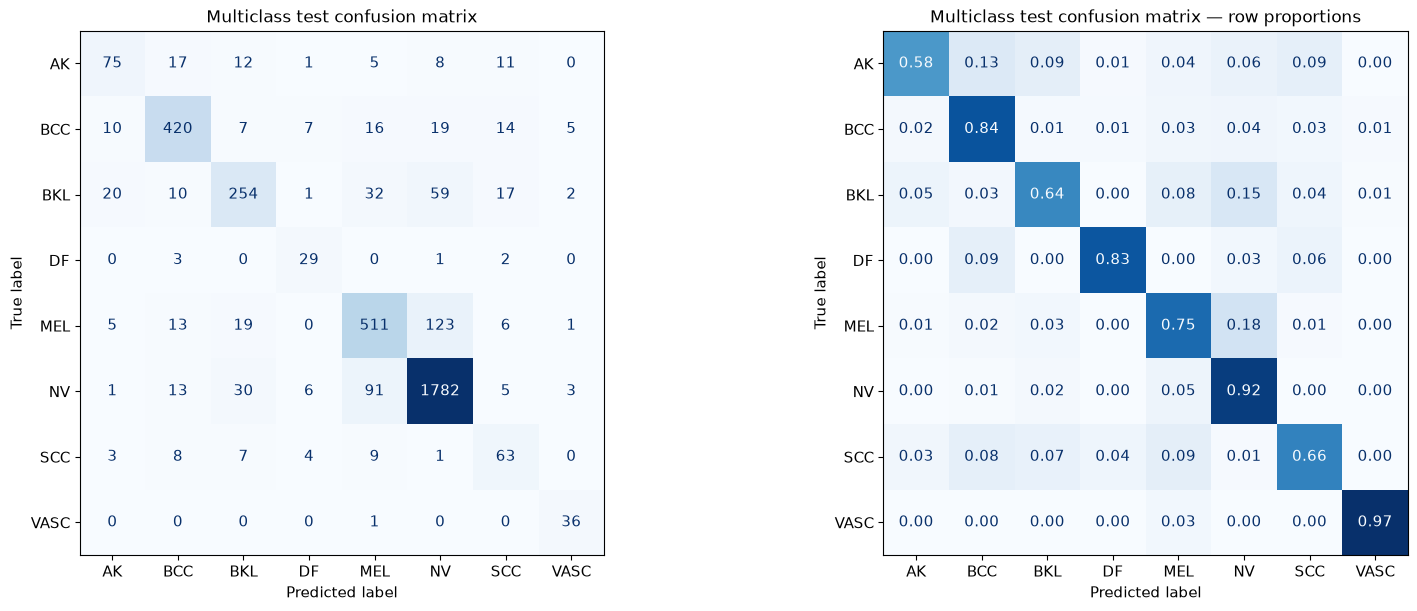

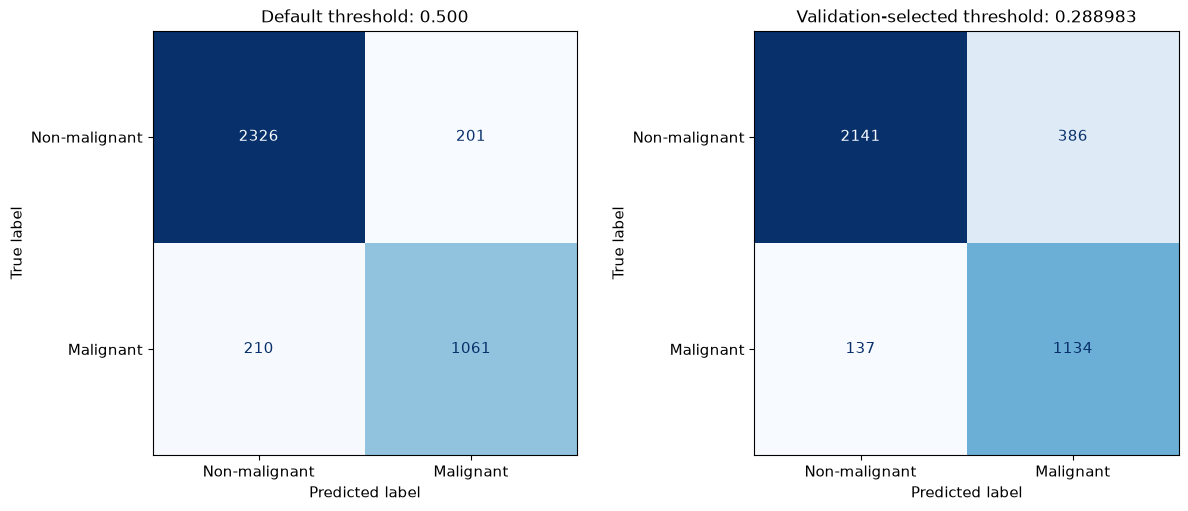

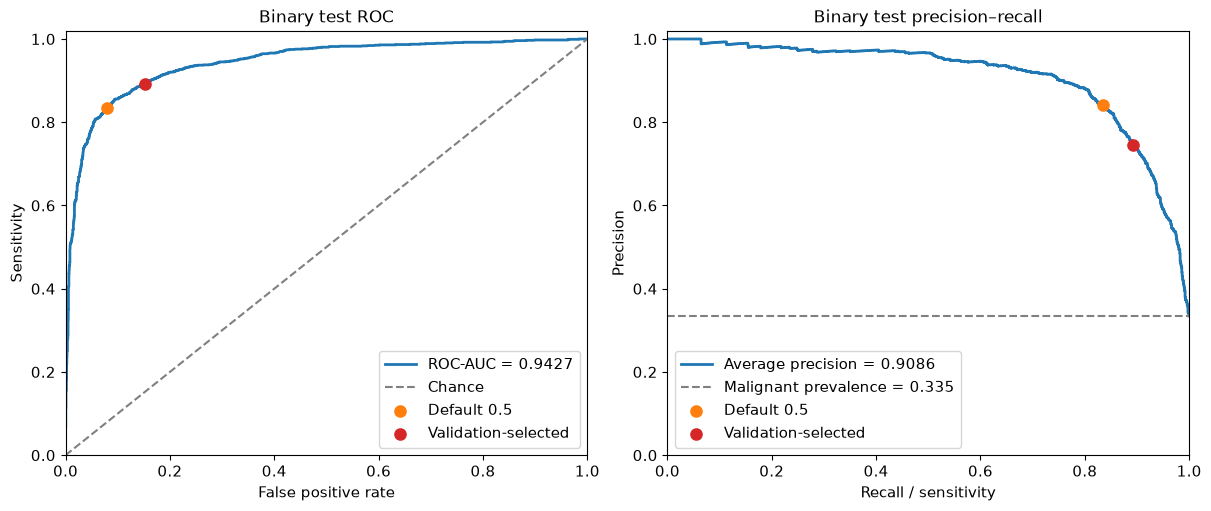

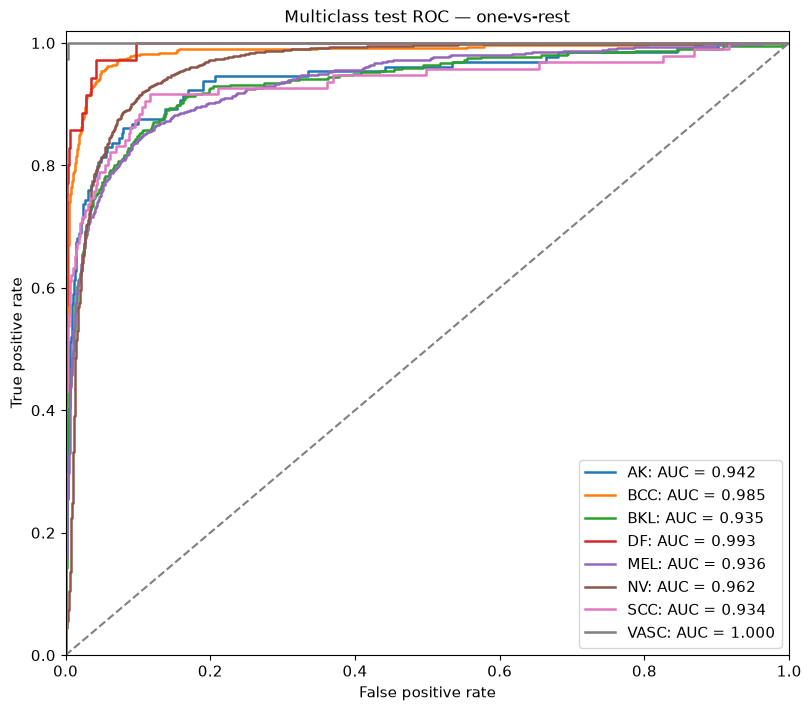

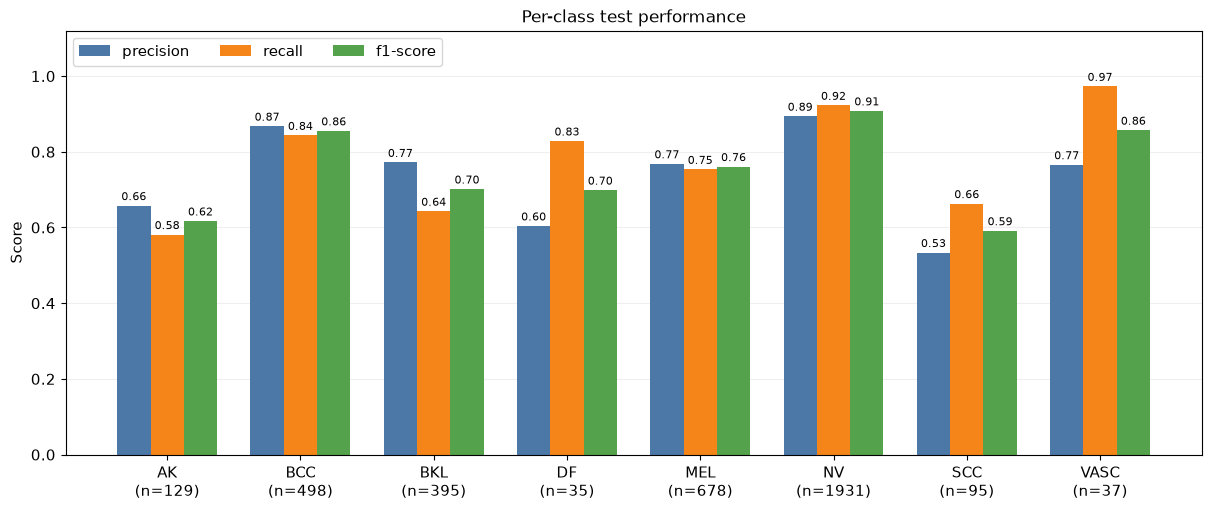

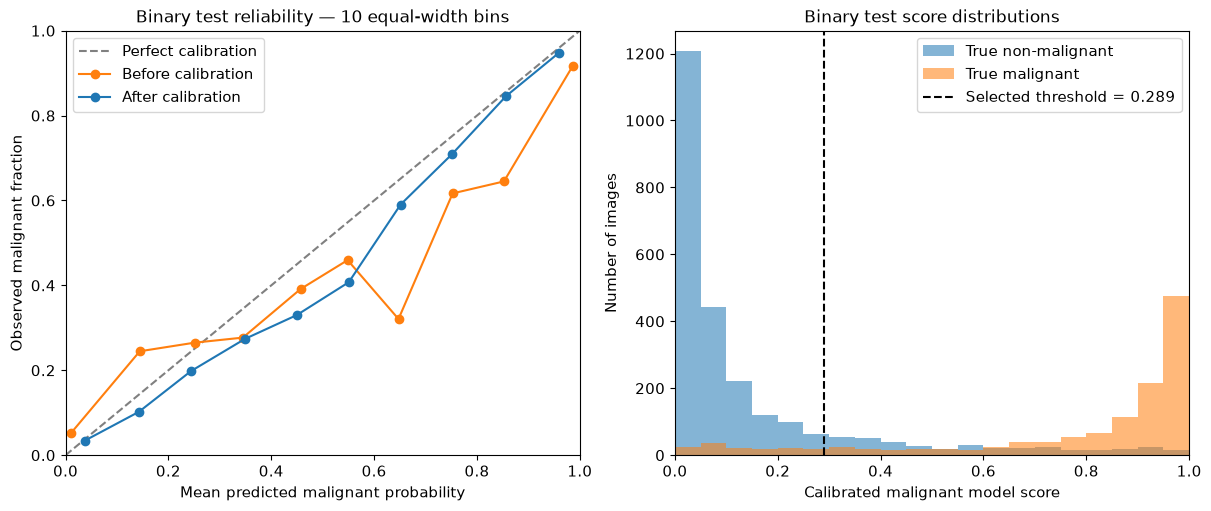

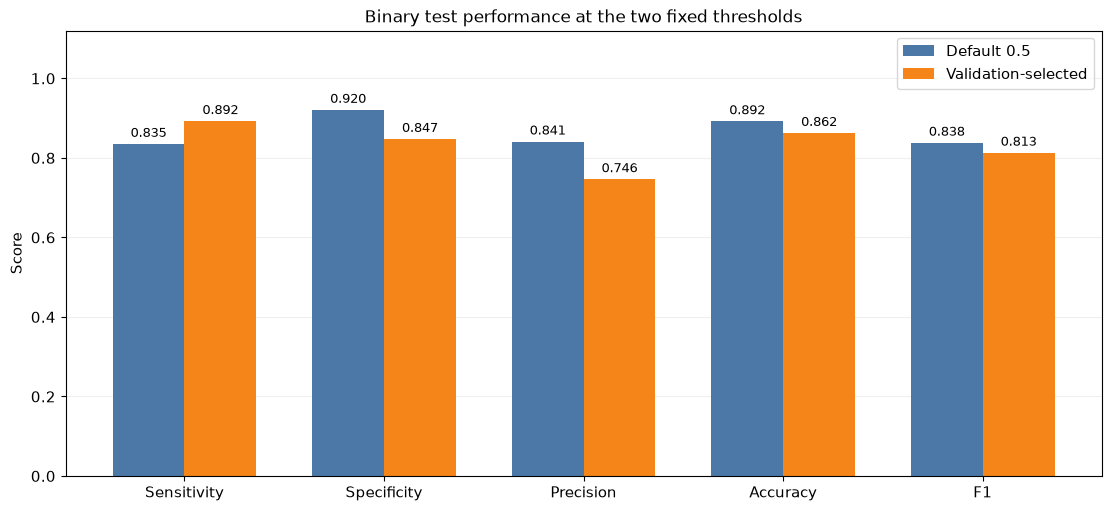


STEP 10 COMPLETED
Figures created: 7
Formats: PNG (300 DPI) and PDF
Saved to: C:\SRS(ISIC_2019)\centralized_finetuning_runs\cb_finetune_retry_20260922_191654_cb7c0476\figures
Model training performed: NO
Model inference performed: NO
Threshold changed: NO


In [34]:
# STEP 10 — Test visualizations
# Uses Step 9 results. No training or model inference.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

required_names = [
    "RUN_DIR",
    "LABEL_NAMES",
    "test_y",
    "test_yb",
    "predicted",
    "raw_binary",
    "calibrated_binary",
    "calibrated_multi",
    "BINARY_THRESHOLD",
    "per_class_metrics",
    "binary_comparison",
    "save_test_csv",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        f"Run Step 9 in this kernel first. Missing: {missing}"
    )

FIGURE_DIR = Path(RUN_DIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

saved_figures = []


def finish_figure(fig, filename):
    # PNG for quick viewing; PDF for thesis export.
    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )
    saved_figures.append(filename)
    plt.show()
    plt.close(fig)


# --------------------------------------------------
# 1. Multiclass confusion matrices
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), constrained_layout=True
)

for ax, normalize, title, fmt in [
    (axes[0], None, "Multiclass test confusion matrix", "d"),
    (
        axes[1], "true",
        "Multiclass test confusion matrix — row proportions",
        ".2f",
    ),
]:
    cm = confusion_matrix(
        test_y,
        predicted,
        labels=np.arange(len(LABEL_NAMES)),
        normalize=normalize,
    )
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=LABEL_NAMES,
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format=fmt,
        colorbar=False,
    )
    ax.set_title(title)

finish_figure(fig, "multiclass_confusion_matrices")


# --------------------------------------------------
# 2. Binary confusion matrices at both frozen rules
# --------------------------------------------------
fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

for ax, threshold, title in [
    (axes[0], 0.5, "Default threshold: 0.500"),
    (
        axes[1],
        BINARY_THRESHOLD,
        f"Validation-selected threshold: {BINARY_THRESHOLD:.6f}",
    ),
]:
    binary_prediction = (
        calibrated_binary >= threshold
    ).astype(int)

    cm = confusion_matrix(
        test_yb, binary_prediction, labels=[0, 1]
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-malignant", "Malignant"],
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False,
    )
    ax.set_title(title)

finish_figure(fig, "binary_confusion_matrices")


# --------------------------------------------------
# 3. Binary ROC and precision–recall curves
# --------------------------------------------------
fpr, tpr, _ = roc_curve(test_yb, calibrated_binary)
precision, recall, _ = precision_recall_curve(
    test_yb, calibrated_binary
)

binary_auc = roc_auc_score(test_yb, calibrated_binary)
binary_ap = average_precision_score(
    test_yb, calibrated_binary
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

axes[0].plot(
    fpr, tpr, linewidth=2,
    label=f"ROC-AUC = {binary_auc:.4f}",
)
axes[0].plot(
    [0, 1], [0, 1], "--", color="gray", label="Chance"
)

for rule, color in [
    ("Default 0.5", "tab:orange"),
    ("Validation-selected", "tab:red"),
]:
    row = binary_comparison.loc[rule]
    axes[0].scatter(
        1 - row["specificity"],
        row["sensitivity"],
        color=color,
        s=65,
        zorder=5,
        label=rule,
    )

axes[0].set(
    xlabel="False positive rate",
    ylabel="Sensitivity",
    title="Binary test ROC",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axes[0].legend(loc="lower right")

axes[1].step(
    recall, precision,
    where="post",
    linewidth=2,
    label=f"Average precision = {binary_ap:.4f}",
)
axes[1].axhline(
    float(np.mean(test_yb)),
    linestyle="--",
    color="gray",
    label=f"Malignant prevalence = {np.mean(test_yb):.3f}",
)

for rule, color in [
    ("Default 0.5", "tab:orange"),
    ("Validation-selected", "tab:red"),
]:
    row = binary_comparison.loc[rule]
    axes[1].scatter(
        row["sensitivity"],
        row["precision"],
        color=color,
        s=65,
        zorder=5,
        label=rule,
    )

axes[1].set(
    xlabel="Recall / sensitivity",
    ylabel="Precision",
    title="Binary test precision–recall",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axes[1].legend(loc="lower left")

finish_figure(fig, "binary_roc_precision_recall")


# --------------------------------------------------
# 4. Multiclass one-vs-rest ROC curves
# --------------------------------------------------
fig, ax = plt.subplots(
    figsize=(8, 7), constrained_layout=True
)

for i, name in enumerate(LABEL_NAMES):
    class_labels = (test_y == i).astype(int)
    class_probabilities = calibrated_multi[:, i]

    class_fpr, class_tpr, _ = roc_curve(
        class_labels, class_probabilities
    )
    class_auc = roc_auc_score(
        class_labels, class_probabilities
    )

    ax.plot(
        class_fpr,
        class_tpr,
        linewidth=1.8,
        label=f"{name}: AUC = {class_auc:.3f}",
    )

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    title="Multiclass test ROC — one-vs-rest",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(loc="lower right")

finish_figure(fig, "multiclass_roc")


# --------------------------------------------------
# 5. Per-class precision, recall and F1
# --------------------------------------------------
class_results = per_class_metrics.reindex(list(LABEL_NAMES))
x = np.arange(len(LABEL_NAMES))
width = 0.25

fig, ax = plt.subplots(
    figsize=(12, 5), constrained_layout=True
)

for offset, metric, color in [
    (-width, "precision", "#4C78A8"),
    (0, "recall", "#F58518"),
    (width, "f1-score", "#54A24B"),
]:
    bars = ax.bar(
        x + offset,
        class_results[metric].to_numpy(),
        width,
        label=metric,
        color=color,
    )
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

ax.set_xticks(
    x,
    [
        f"{name}\n(n={int(class_results.loc[name, 'support'])})"
        for name in LABEL_NAMES
    ],
)
ax.set(
    ylabel="Score",
    title="Per-class test performance",
    ylim=(0, 1.12),
)
ax.legend(loc="upper left", ncol=3)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

finish_figure(fig, "per_class_performance")


# --------------------------------------------------
# 6. Binary reliability diagrams and score distributions
# --------------------------------------------------
def reliability_table(labels, probabilities, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.minimum(
        (probabilities * n_bins).astype(int),
        n_bins - 1,
    )

    rows = []
    for i in range(n_bins):
        mask = bin_ids == i
        if not mask.any():
            continue

        rows.append({
            "bin_lower": float(edges[i]),
            "bin_upper": float(edges[i + 1]),
            "count": int(mask.sum()),
            "mean_probability": float(probabilities[mask].mean()),
            "observed_malignant_fraction": float(labels[mask].mean()),
        })

    return pd.DataFrame(rows)


reliability_raw = reliability_table(test_yb, raw_binary)
reliability_calibrated = reliability_table(
    test_yb, calibrated_binary
)

save_test_csv(
    Path(RUN_DIR) / "reliability_raw.csv",
    reliability_raw,
)
save_test_csv(
    Path(RUN_DIR) / "reliability_calibrated.csv",
    reliability_calibrated,
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

axes[0].plot(
    [0, 1], [0, 1], "--",
    color="gray", label="Perfect calibration",
)

for table, label, color in [
    (reliability_raw, "Before calibration", "tab:orange"),
    (reliability_calibrated, "After calibration", "tab:blue"),
]:
    axes[0].plot(
        table["mean_probability"],
        table["observed_malignant_fraction"],
        marker="o",
        color=color,
        label=label,
    )

axes[0].set(
    xlabel="Mean predicted malignant probability",
    ylabel="Observed malignant fraction",
    title="Binary test reliability — 10 equal-width bins",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[0].legend()

bins = np.linspace(0, 1, 21)

for label, name, color in [
    (0, "True non-malignant", "tab:blue"),
    (1, "True malignant", "tab:orange"),
]:
    axes[1].hist(
        calibrated_binary[test_yb == label],
        bins=bins,
        alpha=0.55,
        color=color,
        label=name,
    )

axes[1].axvline(
    BINARY_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Selected threshold = {BINARY_THRESHOLD:.3f}",
)
axes[1].set(
    xlabel="Calibrated malignant model score",
    ylabel="Number of images",
    title="Binary test score distributions",
    xlim=(0, 1),
)
axes[1].legend()

finish_figure(fig, "calibration_and_scores")


# --------------------------------------------------
# 7. Test trade-off between the two decision rules
# --------------------------------------------------
comparison_metrics = [
    "sensitivity", "specificity", "precision", "accuracy", "f1"
]
x = np.arange(len(comparison_metrics))
width = 0.36

fig, ax = plt.subplots(
    figsize=(11, 5), constrained_layout=True
)

for offset, rule, color in [
    (-width / 2, "Default 0.5", "#4C78A8"),
    (width / 2, "Validation-selected", "#F58518"),
]:
    values = binary_comparison.loc[
        rule, comparison_metrics
    ].to_numpy(dtype=float)

    bars = ax.bar(
        x + offset, values, width,
        label=rule, color=color,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_xticks(x, [name.capitalize() for name in comparison_metrics])
ax.set(
    ylabel="Score",
    title="Binary test performance at the two fixed thresholds",
    ylim=(0, 1.12),
)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

finish_figure(fig, "binary_threshold_comparison")


print("\nSTEP 10 COMPLETED")
print("Figures created:", len(saved_figures))
print("Formats: PNG (300 DPI) and PDF")
print("Saved to:", FIGURE_DIR)
print("Model training performed: NO")
print("Model inference performed: NO")
print("Threshold changed: NO")

### Step 11: saved model backup ও reload verification(2nd Tuning Part)

In [ ]:
# STEP 11 — Back up the completed run and verify model reload
# No training, calibration fitting or threshold selection.

from pathlib import Path
from datetime import datetime
from uuid import uuid4
import hashlib
import json
import os
import shutil

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm


# --------------------------------------------------
# 1. Explicitly select the completed fine-tuning run
# --------------------------------------------------
SOURCE_RUN = Path(
    r"C:\SRS(ISIC_2019)\centralized_finetuning_runs"
    r"\cb_finetune_retry_20260922_191654_cb7c0476"
)
PROJECT_DIR = SOURCE_RUN.parent.parent
BACKUP_ROOT = PROJECT_DIR / "verified_model_backups"

required_definitions = [
    "ISIC_Fusion_Model",
    "val_transform",
    "device",
]
missing = [
    name for name in required_definitions
    if name not in globals()
]
if missing:
    raise RuntimeError(
        f"Run the architecture/transform definitions first: {missing}"
    )

required_files = [
    "best_centralized_model.pth",
    "calibration.json",
    "decision_policy.json",
    "split_validation.csv",
    "test_metrics.json",
    "test_evaluation_provenance.json",
]

for name in required_files:
    path = SOURCE_RUN / name
    if not path.is_file():
        raise FileNotFoundError(path)

# Capture saved notebook code alongside the model.
notebooks = sorted(PROJECT_DIR.glob("*.ipynb"))
if not notebooks:
    raise FileNotFoundError(
        f"No notebooks found in {PROJECT_DIR}. "
        "Save your notebook in the project folder first."
    )


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# --------------------------------------------------
# 2. Copy files into a new temporary backup folder
# --------------------------------------------------
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

backup_name = (
    SOURCE_RUN.name
    + "_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
    + "_"
    + uuid4().hex[:6]
)

FINAL_BACKUP = BACKUP_ROOT / backup_name
STAGING_BACKUP = BACKUP_ROOT / (backup_name + ".incomplete")

STAGING_BACKUP.mkdir(exist_ok=False)

copy_jobs = [
    (path, Path("run") / path.relative_to(SOURCE_RUN))
    for path in sorted(SOURCE_RUN.rglob("*"))
    if path.is_file()
]
copy_jobs += [
    (path, Path("notebooks") / path.name)
    for path in notebooks
]

manifest = {}

for source, relative in tqdm(copy_jobs, desc="Backing up files"):
    destination = STAGING_BACKUP / relative
    destination.parent.mkdir(parents=True, exist_ok=True)

    source_hash = sha256_file(source)

    with source.open("rb") as src, destination.open("wb") as dst:
        shutil.copyfileobj(src, dst, length=1024 * 1024)
        dst.flush()
        os.fsync(dst.fileno())

    if sha256_file(destination) != source_hash:
        raise RuntimeError(f"Backup verification failed: {source}")

    manifest[relative.as_posix()] = source_hash

print("Backup file hashes verified:", len(manifest))


# --------------------------------------------------
# 3. Verify model/calibration/threshold linkage
# --------------------------------------------------
copied_run = STAGING_BACKUP / "run"
model_path = copied_run / "best_centralized_model.pth"
calibration_path = copied_run / "calibration.json"
policy_path = copied_run / "decision_policy.json"

saved_calibration = json.loads(
    calibration_path.read_text(encoding="utf-8")
)
saved_policy = json.loads(
    policy_path.read_text(encoding="utf-8")
)

model_hash = sha256_file(model_path)

if saved_calibration["checkpoint_sha256"] != model_hash:
    raise ValueError("Calibration/checkpoint mismatch.")

if saved_policy["checkpoint_sha256"] != model_hash:
    raise ValueError("Policy/checkpoint mismatch.")

if saved_policy["calibration_sha256"] != sha256_file(calibration_path):
    raise ValueError("Policy/calibration mismatch.")

threshold = float(saved_policy["binary_threshold"])
temperatures = [
    float(saved_calibration["binary_temperature"]),
    float(saved_calibration["multiclass_temperature"]),
]

if not np.isfinite(threshold) or not 0 <= threshold <= 1:
    raise ValueError("Invalid saved threshold.")

if not all(np.isfinite(t) and t > 0 for t in temperatures):
    raise ValueError("Invalid saved temperatures.")


# --------------------------------------------------
# 4. Build a fresh model and restore backup weights
# --------------------------------------------------
checkpoint = torch.load(
    model_path,
    map_location="cpu",
    weights_only=True,
)

classes = tuple(checkpoint["classes"])
malignant_indices = tuple(checkpoint["malignant_indices"])

if classes != ("AK", "BCC", "BKL", "DF", "MEL", "NV", "SCC", "VASC"):
    raise ValueError("Unexpected class mapping.")

if set(malignant_indices) != {1, 4, 6}:
    raise ValueError("Unexpected malignant mapping.")

epoch = int(checkpoint["epoch"])

if (
    epoch != int(saved_calibration["best_epoch"])
    or epoch != int(saved_policy["best_epoch"])
):
    raise ValueError("Saved epoch mismatch.")

restored_model = ISIC_Fusion_Model(
    num_classes=len(classes),
    pretrained=False,
)

restored_model.load_state_dict(
    checkpoint["state_dict"],
    strict=True,
)

# Check every restored parameter and buffer before moving to GPU.
for name, value in restored_model.state_dict().items():
    if not torch.equal(value.cpu(), checkpoint["state_dict"][name].cpu()):
        raise RuntimeError(f"Restored tensor mismatch: {name}")

del checkpoint
restored_model.to(device).eval()

print("Fresh model loaded from backup.")
print("All restored parameters and buffers match the checkpoint.")


# --------------------------------------------------
# 5. One-image inference smoke check
# --------------------------------------------------
validation_manifest = pd.read_csv(
    copied_run / "split_validation.csv"
)
probe_row = validation_manifest.iloc[0]
probe_path = Path(probe_row["image_path"])

if not probe_path.is_file():
    raise FileNotFoundError(probe_path)

if sha256_file(probe_path) != probe_row["sha256"]:
    raise ValueError("Verification image bytes changed.")

with Image.open(probe_path) as image:
    probe = val_transform(
        image.convert("RGB")
    ).unsqueeze(0).to(device)

# FP32 smoke check; it does not recompute test metrics.
with torch.inference_mode():
    outputs = restored_model(probe)

    binary_logits = torch.stack([
        binary.reshape(-1).float()
        for binary, multiclass in outputs
    ]).mean(dim=0)

    multiclass_logits = torch.stack([
        multiclass.float()
        for binary, multiclass in outputs
    ]).mean(dim=0)

if binary_logits.shape != (1,) or multiclass_logits.shape != (1, 8):
    raise RuntimeError("Unexpected restored-model output shapes.")

if (
    not torch.isfinite(binary_logits).all()
    or not torch.isfinite(multiclass_logits).all()
):
    raise RuntimeError("Restored model produced non-finite outputs.")

print("One-image inference check: PASSED")


# --------------------------------------------------
# 6. Record verification and finalize the backup
# --------------------------------------------------
verification = {
    "source_run": str(SOURCE_RUN),
    "best_epoch": epoch,
    "checkpoint_sha256": model_hash,
    "binary_threshold": threshold,
    "classes": list(classes),
    "malignant_indices": list(malignant_indices),
    "copied_files": len(manifest),
    "strict_model_load": "passed",
    "restored_tensor_comparison": "passed",
    "single_image_inference": "passed",
    "verification_image_id": str(probe_row["image_id"]),
    "validation_transform": repr(val_transform),
    "torch_version": str(torch.__version__),
    "device": str(device),
    "note": (
        "Inference reuse verified. Notebook architecture definitions "
        "and dependencies are still required. Exact training resume "
        "requires optimizer, scheduler, scaler and RNG states."
    ),
}

for name, data in [
    ("backup_manifest.json", manifest),
    ("reload_verification.json", verification),
]:
    with (STAGING_BACKUP / name).open(
        "w", encoding="utf-8"
    ) as file:
        json.dump(data, file, indent=2, allow_nan=False)
        file.flush()
        os.fsync(file.fileno())

# Only a fully checked backup receives its final folder name.
STAGING_BACKUP.rename(FINAL_BACKUP)

VERIFIED_BACKUP_DIR = FINAL_BACKUP

# Release the temporary model; keep the existing best_model.
del restored_model, probe, outputs, binary_logits, multiclass_logits
if device.type == "cuda":
    torch.cuda.empty_cache()

print("\nSTEP 11 COMPLETED")
print("Best fine-tuning epoch:", epoch)
print(f"Saved binary threshold: {threshold:.6f}")
print("Backup:", VERIFIED_BACKUP_DIR)
print("Saved notebooks:", [path.name for path in notebooks])
print("Backup integrity: PASSED")
print("Model reload: PASSED")
print("One-image inference: PASSED")
print("Training performed: NO")

Backing up files:   0%|          | 0/42 [00:00<?, ?it/s]

### Federated Learning Simulation (FedAvg)

### Create Client Dataset Split

### Archived original cell 76

```python
import numpy as np
from torch.utils.data import Subset

NUM_CLIENTS = 4


def split_dataset(dataset, num_clients):
    indices = np.arange(len(dataset))
    np.random.shuffle(indices)

    split_indices = np.array_split(indices, num_clients)

    client_datasets = []

    for idx in split_indices:
        client_datasets.append(Subset(dataset, idx))

    return client_datasets


client_datasets = split_dataset(train_dataset, NUM_CLIENTS)

for i, dataset in enumerate(client_datasets):
    print(f"Client {i+1}: {len(dataset)} samples")

```


### Client DataLoader

### Archived original cell 78

```python
from torch.utils.data import DataLoader

client_loaders = []

for dataset in client_datasets:
    loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)
    client_loaders.append(loader)

print("Client DataLoaders created:", len(client_loaders))

```


### Check Client Data

### Archived original cell 80

```python
for i, loader in enumerate(client_loaders):
    images, labels = next(iter(loader))
    print("Client", i + 1, images.shape, labels.shape)

```


### Archived original cell 81

```python
import sys
import os

sys.path.append("./federated")

from client import ISICClient
from server import get_strategy

print("Flower modules loaded")
```


### Archived original cell 82

```python
import copy
import torch

# Use trained global model
fl_global_model = copy.deepcopy(best_model).to(device)
print("Federated global model ready")

```


### Archived original cell 83

```python
def client_fn(cid):
    client_model = copy.deepcopy(fl_global_model)
    client_model = client_model.to(device)

    return ISICClient(
        client_model,
        client_loaders[int(cid)],
        device,
        combined_loss,
        get_binary_label
    ).to_client()
```


### Archived original cell 84

```python
# Test client creation

test_client = client_fn("0")
print(type(test_client))
print("Client created successfully")
```


### Archived original cell 85

```python
# Get FedAvg strategy

strategy = get_strategy()
print("FedAvg strategy ready")
```


### Archived original cell 86

```python
import sys

print(sys.executable)
```


### Archived original cell 87

```python
import sys
import socket
import subprocess
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED

import grpc
import flwr as fl


def run_local_federation():
    project_dir = Path(PROJECT_PATH).resolve()
    server_script = project_dir / "federated" / "server.py"
    log_path = project_dir / "federated_server.log"
    address = "127.0.0.1:8080"

    if not server_script.is_file():
        raise FileNotFoundError(
            f"Server file not found: {server_script}"
        )

    if NUM_CLIENTS != 4 or len(client_loaders) != 4:
        raise ValueError(
            "The current server requires exactly four clients."
        )

    # Check whether another server is already using this port.
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as probe:
        probe.settimeout(1)

        if probe.connect_ex(("127.0.0.1", 8080)) == 0:
            raise RuntimeError(
                "Port 8080 is already in use. Stop the previous "
                "server before running this cell."
            )

    server_process = None
    pool = None

    try:
        with log_path.open("w", encoding="utf-8") as server_log:

            # Start server using the notebook's Python environment.
            server_process = subprocess.Popen(
                [sys.executable, "-u", str(server_script)],
                cwd=str(project_dir),
                stdout=server_log,
                stderr=subprocess.STDOUT,
            )

            print(
                f"Starting server. Log: {log_path}",
                flush=True,
            )

            # Wait until the server accepts a gRPC connection.
            with grpc.insecure_channel(address) as channel:
                ready = grpc.channel_ready_future(channel)
                deadline = time.monotonic() + 60

                while True:
                    if server_process.poll() is not None:
                        raise RuntimeError(
                            f"Server exited during startup. Read {log_path}"
                        )

                    try:
                        ready.result(timeout=1)
                        break

                    except grpc.FutureTimeoutError:
                        if time.monotonic() >= deadline:
                            raise TimeoutError(
                                "Server was not ready within 60 seconds. "
                                f"Read {log_path}"
                            )

            print(
                f"Server ready at {address}. Starting four clients.",
                flush=True,
            )

            def connect_client(cid):
                print(f"Starting client {cid}", flush=True)

                fl.client.start_client(
                    server_address=address,
                    client=client_fn(str(cid)),
                )

            # Connect all four clients.
            pool = ThreadPoolExecutor(max_workers=NUM_CLIENTS)

            futures = {
                pool.submit(connect_client, cid): cid
                for cid in range(NUM_CLIENTS)
            }

            pending = set(futures)

            while pending:
                done, pending = wait(
                    pending,
                    timeout=1,
                    return_when=FIRST_COMPLETED,
                )

                for future in done:
                    try:
                        future.result()

                    except BaseException as exc:
                        raise RuntimeError(
                            f"Client {futures[future]} failed. "
                            f"Read its error and {log_path}"
                        ) from exc

                if server_process.poll() not in (None, 0):
                    raise RuntimeError(
                        f"Server failed. Read {log_path}"
                    )

            return_code = server_process.wait(timeout=30)

            if return_code != 0:
                raise RuntimeError(
                    f"Server exited with code {return_code}. "
                    f"Read {log_path}"
                )

            print(
                "Server and all four clients finished normally. "
                f"Round details: {log_path}"
            )

    finally:
        # Clean up the server started by this cell.
        if server_process is not None and server_process.poll() is None:
            server_process.terminate()

            try:
                server_process.wait(timeout=10)

            except subprocess.TimeoutExpired:
                server_process.kill()
                server_process.wait(timeout=10)

        if pool is not None:
            pool.shutdown(wait=False, cancel_futures=True)


run_local_federation()
```


### Archived original cell 88

```python
import copy
import json
from pathlib import Path

import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score,
)

checkpoint_root = Path(PROJECT_PATH) / "fl_checkpoints"
manifest_path = checkpoint_root / "latest_run.json"

if not manifest_path.is_file():
    raise FileNotFoundError(
        "No saved FL run found. Run the updated server/client cell first."
    )

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

run_dir = Path(manifest["run_dir"])
final_round = manifest["num_rounds"]
weights_path = run_dir / f"round_{final_round}.npz"

if not weights_path.is_file():
    raise FileNotFoundError(
        f"Final checkpoint is missing: {weights_path}. "
        "Check whether all five rounds finished successfully."
    )

# Reuse the existing model architecture.
final_fl_model = copy.deepcopy(best_model).cpu()
reference_state = final_fl_model.state_dict()
loaded_state = {}

with np.load(weights_path, allow_pickle=False) as saved:
    expected_keys = [f"param_{i:05d}" for i in range(len(reference_state))]

    if set(saved.files) != set(expected_keys):
        raise ValueError("Checkpoint parameter count does not match the model.")

    for i, (name, reference) in enumerate(reference_state.items()):
        array = saved[f"param_{i:05d}"]

        if tuple(array.shape) != tuple(reference.shape):
            raise ValueError(
                f"Shape mismatch for {name}: "
                f"{array.shape} versus {tuple(reference.shape)}"
            )

        loaded_state[name] = torch.tensor(
            array,
            dtype=reference.dtype,
        )

final_fl_model.load_state_dict(loaded_state, strict=True)

# Save the actual aggregated global model.
model_path = run_dir / "final_federated_model.pth"
torch.save(final_fl_model.state_dict(), model_path)

print("Final global model saved:", model_path)

final_fl_model = final_fl_model.to(device)
final_fl_model.eval()

# Use the existing prediction function from your notebook.
fl_y_true, fl_y_pred, fl_y_prob = predict(
    final_fl_model,
    test_loader,
    device,
)

class_names = [
    "AK",
    "BCC",
    "BKL",
    "DF",
    "MEL",
    "NV",
    "SCC",
    "VASC",
]

print("\nFEDERATED MODEL TEST RESULTS")
print(f"Accuracy: {accuracy_score(fl_y_true, fl_y_pred):.4f}")
print(
    f"Macro F1: {f1_score(fl_y_true, fl_y_pred, average='macro', zero_division=0):.4f}"
)
print(
    f"Weighted F1: {f1_score(fl_y_true, fl_y_pred, average='weighted', zero_division=0):.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        fl_y_true,
        fl_y_pred,
        labels=list(range(8)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

if len(np.unique(fl_y_true)) == 8:
    auc = roc_auc_score(
        fl_y_true,
        fl_y_prob,
        multi_class="ovr",
        average="macro",
    )
    print(f"Macro ROC-AUC: {auc:.4f}")
else:
    print("ROC-AUC skipped: some classes are absent from the test set.")

```
